<img src="https://github.com/KartikNW/MSDS_458_Public/blob/main/images2/NorthwesternHeader.png?raw=1" />

In [2]:
NOTEBOOK_VERSION = "1.0"
QUARTER = "Spring 2026"

from datetime import datetime
NOTEBOOK_START_TIME = datetime.now()
print(f"Notebook Version: {NOTEBOOK_VERSION} | {QUARTER}")

Notebook Version: 1.0 | Spring 2026


# Assignment 3 — Part A: Building an Encoder–Decoder Transformer from Scratch (Text → Code)

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- Understand how the **encoder–decoder Transformer architecture** replaces recurrence with attention.
- Implement key building blocks:
  - **Positional encoding**
  - **Scaled dot-product attention**
  - **Multi-head attention**
  - **Encoder and decoder blocks**
- Train a small Transformer model to **map natural-language prompts to code snippets**.
- Evaluate generation quality using **token-level accuracy**.
- Compare performance later with a **pretrained model (Part B)**.


## Notebook Overview

- 🧩 Step 1: Setup and Imports
- 📦 Step 1B: Import Shared Utilities
- 🗂️ Step 2: Load and Explore the MBPP Dataset
- 🧮 Step 3: Tokenization and Vocabulary (Text & Code)
- 🧵 Step 4: Build the Encoder–Decoder Training Dataset
- 🔍 Step 5: Positional Encoding and Attention Blocks
- 🏗️ Step 6: Encoder & Decoder Blocks + Full Transformer Model
- 🚂 Step 7: Training the Transformer
- 🧪 Step 8: Generate Code from Prompts (Greedy Decoding)
- 📊 Step 9: BLEU Score Evaluation
- 🎓 Summary: What We Learned

## 🧩 Step 1: Setup and Imports

In this step, you will import all the necessary libraries for building and training an encoder–decoder transformer.

We’ll be using:
- **TensorFlow / Keras** for model construction  
- **Hugging Face Datasets** to load the MBPP dataset  
- **NumPy / Pandas** for data preprocessing  
- **Matplotlib / Seaborn** for visualizations  
- **Evaluate & ROUGE / SacreBLEU** for evaluation metrics


In [3]:
# Uncomment the line below if running on Colab or if packages are not installed
!pip install -q datasets evaluate
print("✅ Packages ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
✅ Packages ready!


In [4]:
# Core dependencies
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import random

# Hugging Face datasets & evaluation libraries
from datasets import load_dataset
import evaluate
from tqdm import tqdm

# For reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("✅ Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


## 📦 Step 1B: Import Shared Utilities

This cell automatically downloads `assignment3_utils.py` if running in Google Colab or if the file is missing locally.

The utilities module provides:
- **Configuration**: MBPP dataset loading and processing
- **Data Loading**: Functions to load and extract dataset examples
- **Data Processing**: Functions to prepare training data
- **BLEU Evaluation**: Functions to evaluate model performance

**Note**: This works seamlessly in both local Jupyter and Google Colab environments.

In [5]:
import os, sys, urllib.request

IN_COLAB = 'google.colab' in sys.modules
UTILS_BRANCH = "main"

def fetch_github_raw(user, repo, branch, file_path, local_path):
    url = f"https://raw.githubusercontent.com/{user}/{repo}/{branch}/{file_path}"
    urllib.request.urlretrieve(url, local_path)
    print(f"Fetched {file_path} from branch '{branch}'.")

if IN_COLAB:
    if not os.path.exists("assignment3_utils.py"):
        fetch_github_raw("KartikNW", "MSDS_458_Public", UTILS_BRANCH,
            "MSDS458_Assignment_03/assignment3_utils.py", "assignment3_utils.py")
else:
    print("Using local assignment3_utils.py")

# Import utilities (Note: DATASET is defined in this notebook, not imported)
from assignment3_utils import (
    # Data loading & processing
    prepare_training_data,
    # BLEU evaluation
    add_python_hint,
    compute_bleu_for_code,
    evaluate_model_with_bleu,
    analyze_bleu_results,
    # Transformer building blocks
    PositionalEncoding,
    ScaledDotProductAttention,
    MultiHeadAttention,
    create_padding_mask,
    create_look_ahead_mask,
    create_decoder_mask,
    point_wise_feed_forward_network,
    EncoderBlock,
    DecoderBlock,
    build_transformer_model,
    # Training utilities
    plot_training_history,
    # Decoding & generation
    ids_to_code_text,
    strip_special_tokens_from_target,
    generate_code_for_prompt,
    generate_best,
    # Batch generation
    sequential_generate_codes,
)

print("✅ Utilities imported successfully")

Fetched MSDS458_Assignment_03/assignment3_utils.py from branch 'main'.
✅ assignment3_utils v1.0.1 loaded successfully
✅ Utilities imported successfully


  ## 🗂️ Step 2: Load and Explore the MBPP Dataset

  In this step, you will:

  - Load the **MBPP** (Mostly Basic Python Problems) dataset using Hugging Face `datasets`
  - Explore the dataset structure with train/validation/test splits
  - Look at a few examples of:
    - The **problem description** (natural language prompt)
    - The corresponding **Python solution code**

  MBPP contains 974 Python programming problems with solutions, split into:
  - **Train**: 374 examples
  - **Validation**: 90 examples
  - **Test**: 50 examples

In [6]:
# ========================================
# LOAD AND PROCESS MBPP DATASET
# ========================================

print("Loading and processing MBPP dataset...")
print("This uses shared utilities from assignment3_utils.py")
print("=" * 60)

# Load and process all splits using shared utility
data = prepare_training_data("MBPP")

# Extract data into variables (maintaining compatibility with rest of notebook)
train_prompts = data['train']['prompts']
train_code = data['train']['code']

val_prompts = data['val']['prompts']
val_code = data['val']['code']

test_prompts = data['test']['prompts']
test_code = data['test']['code']

print("=" * 60)
print(f"📊 Dataset sizes:")
print(f"  Train: {len(train_prompts)}")
print(f"  Val: {len(val_prompts)}")
print(f"  Test: {len(test_prompts)}")
print("✅ Dataset loaded and processed successfully!")
print("\nNote: START/END tokens will be added after they are defined below.")

Loading and processing MBPP dataset...
This uses shared utilities from assignment3_utils.py


README.md:   0%|          | 0.00/9.06k [00:00<?, ?B/s]

full/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 87.2kB            

full/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

full/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  116kB            

...

Generating train split:   0%|          | 0/374 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/90 [00:00<?, ? examples/s]

Generating prompt split:   0%|          | 0/10 [00:00<?, ? examples/s]

Processing MBPP dataset...
  Train: 374 examples
  Val: 90 examples
  Test: 50 examples
📊 Dataset sizes:
  Train: 374
  Val: 90
  Test: 50
✅ Dataset loaded and processed successfully!

Note: START/END tokens will be added after they are defined below.


In [7]:
# ========================================
# PREVIEW DATASET EXAMPLES
# ========================================

print("📋 Sample training examples:")
print("=" * 80)

for i in range(3):
    print(f"\nExample {i+1}:")
    print("-" * 80)
    print(f"📝 Prompt: {train_prompts[i][:200]}{'...' if len(train_prompts[i]) > 200 else ''}")
    print(f"💻 Code:   {train_code[i][:200]}{'...' if len(train_code[i]) > 200 else ''}")

print("=" * 80)

📋 Sample training examples:

Example 1:
--------------------------------------------------------------------------------
📝 Prompt: Write a function to find the longest chain which can be formed from the given set of pairs.
💻 Code:   class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)] 
	for i in range(1, n): 
		for j in range(0, i...

Example 2:
--------------------------------------------------------------------------------
📝 Prompt: Write a python function to find the first repeated character in a given string.
💻 Code:   def first_repeated_char(str1):
  for index,c in enumerate(str1):
    if str1[:index+1].count(c) > 1:
      return c 
  return "None"

Example 3:
--------------------------------------------------------------------------------
📝 Prompt: Write a function to get a lucid number smaller than or equal to n.
💻 Code:   def get_ludic(n):
	ludics = []
	for i in range(1, n + 1):
		ludic

## 🧮 Step 3: Tokenization and Vocabulary (Text & Code)

In this step, you will:

- Build **separate tokenizers** for:
  - Input prompts (natural language descriptions)
  - Output sequences (Python code)
- Add special tokens for the target side:
  - `"[START]"` to mark the beginning of a code sequence
  - `"[END]"` to mark the end of a code sequence
- Convert raw text/code into **integer sequences** that your Transformer can use.


You will be using Keras `TextVectorization` layers to:
- Learn a vocabulary from the dataset
- Map each token to an integer id
- Pad/trim all sequences to a fixed maximum length

In [8]:
from tensorflow.keras.layers import TextVectorization

# 🔧 Hyperparameters for tokenization
# --- EXPERIMENT HERE: vocabulary sizes and sequence lengths ---
MAX_INPUT_TOKENS = 12000   # vocabulary size for prompts
MAX_TARGET_TOKENS = 20000  # vocabulary size for code
MAX_INPUT_LENGTH = 128     # max tokens in the prompt
MAX_TARGET_LENGTH = 256    # max tokens in the code

START_TOKEN = "[START]"
END_TOKEN = "[END]"

print(f"✅ Updated vocabulary sizes:")
print(f"   Input vocab: {MAX_INPUT_TOKENS}")
print(f"   Target vocab: {MAX_TARGET_TOKENS}")

✅ Updated vocabulary sizes:
   Input vocab: 12000
   Target vocab: 20000


In [9]:
# ========================================
# ADD START/END TOKENS TO TARGETS
# ========================================

# Now that START_TOKEN and END_TOKEN are defined, add them to target sequences
train_inputs = train_prompts
train_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in train_code]

val_inputs = val_prompts
val_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in val_code]

test_inputs = test_prompts
test_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in test_code]

print(f"✅ Added START and END tokens to target sequences")
print(f"   Example target (first 100 chars): {train_targets[0][:100]}...")

✅ Added START and END tokens to target sequences
   Example target (first 100 chars): [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_cha...


In [10]:
# 🔹 Combine all data for vocabulary building

input_texts = train_inputs + val_inputs + test_inputs
target_texts = train_targets + val_targets + test_targets

print(f"Total examples for vocabulary: {len(input_texts)}")
print("\nSample description:\n", input_texts[0][:200], "...")
print("\nSample target with tokens:\n", target_texts[0][:200], "...")

Total examples for vocabulary: 514

Sample description:
 Write a function to find the longest chain which can be formed from the given set of pairs. ...

Sample target with tokens:
 [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)] 
	for i in range(1, n): 
		for j in ra ...


In [11]:
# 🔹 Define simple standardization functions
# For this assignment, you will keep things relatively simple:
# - Lowercase everything
# - Do not aggressively strip punctuation (especially for code)

def simple_standardize_text(text):
    text = tf.strings.lower(text)
    return text

def simple_standardize_code(text):
    # You could customize this later if you want to handle code differently.
    text = tf.strings.lower(text)
    return text

In [12]:
# 🔹 Create TextVectorization layers for input (prompts) and target (code)

# Input (natural language prompt) vectorizer
input_vectorizer = TextVectorization(
    standardize=simple_standardize_text,
    max_tokens=MAX_INPUT_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_INPUT_LENGTH,
)

# Target (code) vectorizer
target_vectorizer = TextVectorization(
    standardize=simple_standardize_code,
    max_tokens=MAX_TARGET_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_TARGET_LENGTH,
)

# Adapt on the training text
input_vectorizer.adapt(input_texts)
target_vectorizer.adapt(target_texts)

print("✅ Vectorizers adapted on MBPP text and code.")

✅ Vectorizers adapted on MBPP text and code.


In [13]:
# 🔹 Inspect a few tokenized sequences

example_idx = 0

print("Original prompt:")
print(input_texts[example_idx])
print("\nVectorized prompt (first 40 ids):")
print(input_vectorizer([input_texts[example_idx]])[0][:40].numpy())

print("\nOriginal target with [START]/[END]:")
print(target_texts[example_idx])
print("\nVectorized target (first 40 ids):")
print(target_vectorizer([target_texts[example_idx]])[0][:40].numpy())

Original prompt:
Write a function to find the longest chain which can be formed from the given set of pairs.

Vectorized prompt (first 40 ids):
[  4   2   5   3   9   6 164 712  69  99  90 193  15   6   8 152   7 537
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]

Original target with [START]/[END]:
[START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)] 
	for i in range(1, n): 
		for j in range(0, i): 
			if (arr[i].a > arr[j].b and
				mcl[i] < mcl[j] + 1): 
				mcl[i] = mcl[j] + 1
	for i in range(n): 
		if (max < mcl[i]): 
			max = mcl[i] 
	return max [END]

Vectorized target (first 40 ids):
[   5  700 1442    4  739  140  158 1187    2   49 1186    2   53    4
 1659   34   92    2   14 1624    2  422    8   11    7  211    8   11
    7   70   34    8   26    7   64  219    9 2850   29 2460]


## 🧵 Step 4: Build the Encoder–Decoder Training Dataset

In this step, you will:

- Turn raw `input_texts` (prompts) and `target_texts` (code with `[START]` / `[END]`) into **integer tensors**.
- Create:
  - `encoder_inputs` → goes into the encoder
  - `decoder_inputs` → goes into the decoder (shifted right, starting with `[START]`)
  - `decoder_targets` → what the model should predict at each time step
- Split the data into **train / validation / test** sets.
- Wrap everything in a `tf.data.Dataset` pipeline for efficient training.

You will be using the **teacher forcing** setup:

- `decoder_inputs`: `[START] token_1 token_2 ... token_(N-1)`
- `decoder_targets`: `token_1 token_2 ... token_(N-1) [END]`


In [14]:
# 🔧 Hyperparameters for data pipeline
BATCH_SIZE = 32

# (Optional) separate constant for decoder sequence length:
DECODER_SEQ_LEN = MAX_TARGET_LENGTH - 1  # because we are shifting by 1

In [15]:
# 🔹 Vectorize all input and target texts

# Convert Python lists to numpy arrays for vectorization
input_texts_array = np.array(input_texts)
target_texts_array = np.array(target_texts)

encoder_input_data = input_vectorizer(input_texts_array)
full_target_data   = target_vectorizer(target_texts_array)

print("Encoder input shape:", encoder_input_data.shape)
print("Full target shape:", full_target_data.shape)

Encoder input shape: (514, 128)
Full target shape: (514, 256)


In [16]:
# 🔹 Build decoder input and target sequences (shifted)

# decoder_inputs: all tokens except the last
decoder_input_data = full_target_data[:, :-1]

# decoder_targets: all tokens except the first (shifted left by one)
decoder_target_data = full_target_data[:, 1:]

print("Decoder input shape:", decoder_input_data.shape)
print("Decoder target shape:", decoder_target_data.shape)

Decoder input shape: (514, 255)
Decoder target shape: (514, 255)


In [17]:
# 🔹 Vectorize the already-split datasets

# Training data
train_input_array = np.array(train_inputs)
train_target_array = np.array(train_targets)

train_encoder_in = input_vectorizer(train_input_array)
train_full_target = target_vectorizer(train_target_array)
train_decoder_in = train_full_target[:, :-1]
train_decoder_tgt = train_full_target[:, 1:]

# Validation data
val_input_array = np.array(val_inputs)
val_target_array = np.array(val_targets)

val_encoder_in = input_vectorizer(val_input_array)
val_full_target = target_vectorizer(val_target_array)
val_decoder_in = val_full_target[:, :-1]
val_decoder_tgt = val_full_target[:, 1:]

# Test data
test_input_array = np.array(test_inputs)
test_target_array = np.array(test_targets)

test_encoder_in = input_vectorizer(test_input_array)
test_full_target = target_vectorizer(test_target_array)
test_decoder_in = test_full_target[:, :-1]
test_decoder_tgt = test_full_target[:, 1:]

print("✅ Data vectorized and split")
print(f"Train encoder shape: {train_encoder_in.shape}")
print(f"Train decoder input shape: {train_decoder_in.shape}")
print(f"Train decoder target shape: {train_decoder_tgt.shape}")
print(f"\nVal encoder shape: {val_encoder_in.shape}")
print(f"Test encoder shape: {test_encoder_in.shape}")

✅ Data vectorized and split
Train encoder shape: (374, 128)
Train decoder input shape: (374, 255)
Train decoder target shape: (374, 255)

Val encoder shape: (90, 128)
Test encoder shape: (50, 128)


In [18]:
# 🔹 Helper function to create a tf.data.Dataset

def make_transformer_dataset(encoder_inputs, decoder_inputs, decoder_targets, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            "encoder_inputs": encoder_inputs,
            "decoder_inputs": decoder_inputs,
        },
        decoder_targets,
    ))
    dataset = dataset.shuffle(buffer_size=len(encoder_inputs), seed=SEED)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_transformer_dataset(train_encoder_in, train_decoder_in, train_decoder_tgt)
val_ds   = make_transformer_dataset(val_encoder_in,   val_decoder_in,   val_decoder_tgt)
test_ds  = make_transformer_dataset(test_encoder_in,  test_decoder_in,  test_decoder_tgt)

train_ds, val_ds, test_ds

(<_PrefetchDataset element_spec=({'encoder_inputs': TensorSpec(shape=(None, 128), dtype=tf.int64, name=None), 'decoder_inputs': TensorSpec(shape=(None, 255), dtype=tf.int64, name=None)}, TensorSpec(shape=(None, 255), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=({'encoder_inputs': TensorSpec(shape=(None, 128), dtype=tf.int64, name=None), 'decoder_inputs': TensorSpec(shape=(None, 255), dtype=tf.int64, name=None)}, TensorSpec(shape=(None, 255), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=({'encoder_inputs': TensorSpec(shape=(None, 128), dtype=tf.int64, name=None), 'decoder_inputs': TensorSpec(shape=(None, 255), dtype=tf.int64, name=None)}, TensorSpec(shape=(None, 255), dtype=tf.int64, name=None))>)

In [19]:
# 🔹 Peek at one batch to verify shapes

for batch in train_ds.take(1):
    batch_inputs, batch_targets = batch
    print("Keys in batch_inputs:", batch_inputs.keys())
    print("encoder_inputs shape:", batch_inputs["encoder_inputs"].shape)
    print("decoder_inputs shape:", batch_inputs["decoder_inputs"].shape)
    print("decoder_targets shape:", batch_targets.shape)

Keys in batch_inputs: dict_keys(['encoder_inputs', 'decoder_inputs'])
encoder_inputs shape: (32, 128)
decoder_inputs shape: (32, 255)
decoder_targets shape: (32, 255)


## 🔍 Step 5: Positional Encoding and Attention Blocks

In this step, we introduce the **core building blocks** of a Transformer:

- A **positional encoding** layer so the model knows the order of tokens.
- **Scaled dot-product attention** (the fundamental attention operation).
- **Multi-head attention**, which runs attention in parallel over multiple "heads".
- **Attention masks** to hide padding and future tokens.

These components are implemented in `assignment3_utils.py`. Below, we explain
what each one does and run sanity checks to verify they work.

All diagrams are from the original Transformer paper:

*Vaswani et al., "Attention Is All You Need" (2017) — [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)*

In [20]:
# Core Transformer hyperparameters
# --- EXPERIMENT HERE: model dimensions (D_MODEL must be divisible by NUM_HEADS) ---
D_MODEL = 256      # embedding / model dimension
NUM_HEADS = 4      # number of attention heads
D_FF = 512         # feed-forward layer dimension (will be used later in blocks)
DROPOUT_RATE = 0.1

### 5.1 Positional Encoding

Transformers have no built-in notion of sequence order (unlike RNNs).
**Positional encodings** are added to token embeddings so the model can
distinguish "first token" from "second token", etc.

The classic **sinusoidal positional encoding** from the original paper uses:

```
PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
```

- Uses `sin` for even dimensions and `cos` for odd dimensions
- Fixed pattern — no extra learnable parameters
- Added directly to the embedding vectors

<img src="https://arxiv.org/html/1706.03762v7/Figures/ModalNet-19.png" width="500" alt="Scaled Dot-Product Attention">

*Source: Vaswani et al., "Attention Is All You Need" (2017) — [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)*

📖 *Full implementation:* `PositionalEncoding` *in* `assignment3_utils.py`

In [21]:
# Sanity check: create layer, pass zeros, verify shape
sample_pe_layer = PositionalEncoding(max_length=MAX_TARGET_LENGTH, d_model=D_MODEL)
test_input = tf.zeros((2, 10, D_MODEL))  # dummy batch
test_output = sample_pe_layer(test_input)
print("Positional encoding output shape:", test_output.shape)

Positional encoding output shape: (2, 10, 256)


### 5.2 Scaled Dot-Product Attention

The **scaled dot-product attention** is the core operation behind every
attention layer in the Transformer.

Given three inputs:
- **Query (Q)** — what we're looking for
- **Key (K)** — what we're matching against
- **Value (V)** — the information we retrieve

The operation computes:

```
Attention(Q, K, V) = softmax( Q · Kᵀ / √d_k ) · V
```

📖 *Full implementation:* `ScaledDotProductAttention` *in* `assignment3_utils.py`

In [22]:
# Sanity check: pass random Q, K, V tensors through attention
temp_attn = ScaledDotProductAttention()
dummy_q = tf.random.uniform((2, 4, 10, 64))  # (batch, heads, seq_len, depth)
dummy_k = tf.random.uniform((2, 4, 10, 64))
dummy_v = tf.random.uniform((2, 4, 10, 64))
out, weights = temp_attn(dummy_q, dummy_k, dummy_v, mask=None)
print("Attention output shape:", out.shape)
print("Attention weights shape:", weights.shape)

Attention output shape: (2, 4, 10, 64)
Attention weights shape: (2, 4, 10, 10)


### 5.3 Multi-Head Attention

**Multi-head attention** wraps scaled dot-product attention by running it
in parallel across multiple "heads":

1. Project Q, K, V into `num_heads` smaller subspaces
2. Run scaled dot-product attention **independently** on each head
3. Concatenate all head outputs
4. Apply a final linear projection

<img src="https://arxiv.org/html/1706.03762v7/Figures/ModalNet-20.png" width="500" alt="Multi-Head Attention">

*Source: Vaswani et al., "Attention Is All You Need" (2017) — [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)*

📖 *Full implementation:* `MultiHeadAttention` *in* `assignment3_utils.py`

In [23]:
# Sanity check: pass random Q, K, V through multi-head attention
temp_mha = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS)
dummy_q = tf.random.uniform((2, 10, D_MODEL))  # (batch, seq_len, d_model)
dummy_k = tf.random.uniform((2, 10, D_MODEL))
dummy_v = tf.random.uniform((2, 10, D_MODEL))

out, attn_w = temp_mha(v=dummy_v, k=dummy_k, q=dummy_q, mask=None)
print("Multi-head output shape:", out.shape)
print("Attention weights shape:", attn_w.shape)

Multi-head output shape: (2, 10, 256)
Attention weights shape: (2, 4, 10, 10)


### 5.4 Attention Masks

Transformers use **masks** so the model doesn't attend to positions it shouldn't:

- **Padding mask**: hides padding tokens (id `0`). Shape: `(batch, 1, 1, seq_len)`
- **Look-ahead mask**: hides *future* tokens in the decoder (causal masking). Shape: `(seq_len, seq_len)`
- **Decoder mask**: combines both — `max(look_ahead, padding)`. Shape: `(batch, 1, seq_len, seq_len)`

📖 *Full implementation:* `create_padding_mask`, `create_look_ahead_mask`,
`create_decoder_mask` *in* `assignment3_utils.py`

In [24]:
# Sanity check: create masks from dummy sequences
dummy_seq = tf.constant([[7, 3, 0, 0, 0], [5, 2, 8, 0, 0]])
pad_mask = create_padding_mask(dummy_seq)
la_mask = create_look_ahead_mask(5)
dec_mask = create_decoder_mask(dummy_seq)
print("Padding mask shape:", pad_mask.shape)
print("Look-ahead mask shape:", la_mask.shape)
print("Decoder mask shape:", dec_mask.shape)



Padding mask shape: (2, 1, 1, 5)
Look-ahead mask shape: (5, 5)
Decoder mask shape: (2, 1, 5, 5)


## 🏗️ Step 6: Encoder & Decoder Blocks + Full Transformer Model

In this step, we assemble the building blocks from Step 5 into:

- An **Encoder Block** (self-attention + FFN)
- A **Decoder Block** (masked self-attention + cross-attention + FFN)
- The **full encoder–decoder transformer model**

All implementations are in `assignment3_utils.py`.

### 6.1 Feed-Forward Network (FFN)

Every encoder and decoder block contains a small **position-wise feed-forward network**:

```
FFN(x) = Dense(d_ff, relu) → Dense(d_model)
```

Applied independently to every position in the sequence.

📖 *Full implementation:* `point_wise_feed_forward_network` *in* `assignment3_utils.py`

### 6.2 Encoder Block

Each `EncoderBlock` contains two sub-layers with **residual connections + LayerNorm**:

```
Input → Multi-Head Self-Attention → Add & Norm → FFN → Add & Norm → Output
```

📖 *Full implementation:* `EncoderBlock` *in* `assignment3_utils.py`

In [25]:
# Sanity check: pass dummy input through an encoder block
enc_block = EncoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_enc_input = tf.random.uniform((2, 10, D_MODEL))
enc_out = enc_block(dummy_enc_input, None, training=False)
print("Encoder block output shape:", enc_out.shape)

Encoder block output shape: (2, 10, 256)


### 6.3 Decoder Block

Each `DecoderBlock` contains **three** sub-layers:

1. **Masked Self-Attention** — prevents looking ahead to future tokens
2. **Cross-Attention** — Q from decoder, K/V from encoder output
3. **Feed-Forward Network**

<img src="https://arxiv.org/html/1706.03762v7/Figures/ModalNet-21.png" width="500" alt="Transformer Architecture">

*Source: Vaswani et al., "Attention Is All You Need" (2017) — [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)*

📖 *Full implementation:* `DecoderBlock` *in* `assignment3_utils.py`

In [26]:
# Sanity check: pass dummy inputs through a decoder block
dec_block = DecoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_dec_input = tf.random.uniform((2, 8, D_MODEL))
dummy_enc_output = tf.random.uniform((2, 10, D_MODEL))
dec_out, _, _ = dec_block(dummy_dec_input, dummy_enc_output,
                          look_ahead_mask=None, padding_mask=None, training=False)
print("Decoder block output shape:", dec_out.shape)

Decoder block output shape: (2, 8, 256)


### 6.4 Full Transformer Model

The full model assembles everything:

- **Encoder**: Embedding → Positional Encoding → N × EncoderBlock
- **Decoder**: Embedding → Positional Encoding → N × DecoderBlock
- **Output**: Dense layer projecting to target vocabulary (softmax)

📖 *Full implementation:* `build_transformer_model` *in* `assignment3_utils.py`

### 6.5 Build and Summarize

In [27]:
input_vocab_size = len(input_vectorizer.get_vocabulary())
target_vocab_size = len(target_vectorizer.get_vocabulary())

# --- EXPERIMENT HERE: num_layers controls model depth ---
transformer = build_transformer_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    num_layers=2,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout_rate=DROPOUT_RATE,
    max_input_len=MAX_INPUT_LENGTH,
    max_target_len=MAX_TARGET_LENGTH - 1,
)

transformer.summary(line_length=120, expand_nested=True)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ encoder_inputs (InputLayer)       │ (None, 128)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding (Embedding)             │ (None, 128, 256)             │           198,912 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_inputs (InputLayer)       │ (None, 255)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_1             │ (None, 128, 256)             │                 0 │ embedding[0][0]           
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_1 (Embedding)           │ (None, 255, 256)             │           771,072 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_5 (Dropout)               │ (None, 128, 256)             │                 0 │ positional_encoding_1[0][0
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda (Lambda)                   │ (None, 1, 1, 128)            │                 0 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_2             │ (None, 255, 256)             │                 0 │ embedding_1[0][0]         
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_1 (EncoderBlock)    │ (None, 128, 256)             │           527,104 │ dropout_5[0][0], lambda[0]
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_10 (Dropout)              │ (None, 255, 256)             │                 0 │ positional_encoding_2[0][0
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_2 (EncoderBlock)    │ (None, 128, 256)             │           527,104 │ encoder_block_1[0][0],    
│                                   │                              │                   │ lambda[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_1 (Lambda)                 │ (None, 1, 255, 255)          │                 0 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_block_1 (DecoderBlock)    │ [(None, 255, 256), (None, 4, │           790,784 │ dropout_10[0][0],         
│                                   │ 255, 255), (None, 4, None,   │                   │ encoder_block_2[0][0],    
│                                   │ 128)]                        │                   │ lambda_1[0][0], lambda[0][
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_block_2 (DecoderBlock)    │ [(None, 255, 256),

 Total params: 4,379,844 (16.71 MB)

 Trainable params: 4,379,844 (16.71 MB)

 Non-trainable params: 0 (0.00 B)

### 6.7 Compile the Transformer

You will use:

- `SparseCategoricalCrossentropy`  
- `Adam` optimizer  
- Token-level accuracy  


In [28]:
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)

transformer.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # --- EXPERIMENT HERE: learning rate ---
    loss=loss_fn,
    metrics=["accuracy"],
)

print("✅ Transformer ready to train!")

✅ Transformer ready to train!


## 🚂 Step 7: Training the Transformer

In this step, you will:

- Train your encoder–decoder transformer
- Use:
  - `EarlyStopping` to stop when validation performance stops improving.
  - `ModelCheckpoint` to save the best model during training.
- Visualize training & validation:
  - Loss curves
  - Accuracy curves
- Evaluate the final model on the **test set**.

You can tweak:

- `EPOCHS`
- `BATCH_SIZE`
- Model depth (`num_layers`)  

to balance **training time** and **performance** in Colab.


In [29]:
EPOCHS = 20  # --- EXPERIMENT HERE: increase for better performance ---

In [30]:
checkpoint_path = "transformer_mbpp.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

print(f"✅ Model will be saved to: {checkpoint_path}")
print("✅ Callbacks set up. Ready to train!")

✅ Model will be saved to: transformer_mbpp.keras
✅ Callbacks set up. Ready to train!


### 7.1 Fit the Model

You will now train the model on:

- `train_ds` for learning
- `val_ds` for monitoring generalization

The model will:

- Save the **best checkpoint** to `transformer_mbpp.keras`
- Stop early if validation loss stops improving for a few epochs


In [31]:
history = transformer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5111 - loss: 6.4284  
Epoch 1: val_loss improved from None to 2.87104, saving model to transformer_mbpp.keras

Epoch 1: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7479 - loss: 5.0464 - val_accuracy: 0.8967 - val_loss: 2.8710
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9049 - loss: 2.7857
Epoch 2: val_loss improved from 2.87104 to 2.02438, saving model to transformer_mbpp.keras

Epoch 2: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.9038 - loss: 2.5761 - val_accuracy: 0.8967 - val_loss: 2.0244
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9077 - loss: 2.0282
Epoch 3: val_loss improved from 2.02438 to 1.66412, saving model to transformer_mbpp.keras

Epoch 3: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.9038 - loss: 1

### 7.2 Plot Training and Validation Curves

You will now plot:

- Training vs. validation **loss**
- Training vs. validation **accuracy**

This helps you see if the model is:

- Underfitting (both losses high)
- Overfitting (training loss ↓ but val loss ↑)


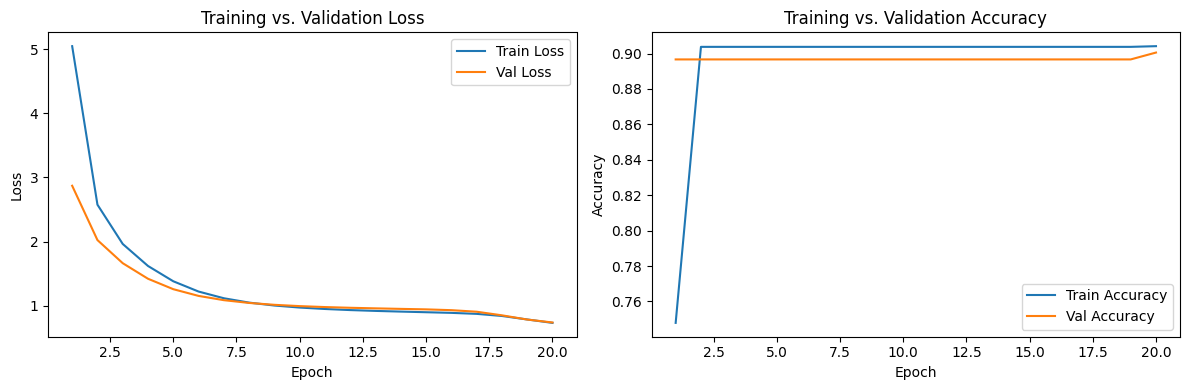

In [32]:
plot_training_history(history)

### 7.3 Evaluate on the Test Set

Once training is done, you will evaluate the model on the **held-out test set**:

- This gives you an unbiased estimate of how well the model generalizes.
- You will look at:
  - Token-level **loss**
  - Token-level **accuracy**


In [33]:
test_loss, test_accuracy = transformer.evaluate(test_ds)
print(f"🧪 Test Loss: {test_loss:.4f}")
print(f"🧪 Test Accuracy (token-level): {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9005 - loss: 0.7360
🧪 Test Loss: 0.7360
🧪 Test Accuracy (token-level): 0.9005


## 🧪 Step 8: Generate Code from Prompts (Greedy Decoding)

In this step, you will:

- Turn a **natural language prompt** into **generated Python code** using your trained Transformer.
- Implement **greedy decoding**:
  - Start with a `[START]` token
  - At each step, pick the most likely next token
  - Stop when you reach `[END]` or a max length
- Compare:
  - Ground-truth code vs.
  - Model-generated code

You will be using the already-trained `transformer` model from Step 7 (no need to reload).


### 8.1 Helper Functions: Vocab & Decoding

The decoding utility functions are already imported from `assignment3_utils.py`:

- `ids_to_code_text(token_ids, id_to_token, start_token, end_token)` — converts a token id sequence to a code string
- `strip_special_tokens_from_target(raw_target_str)` — removes `[START]` / `[END]` markers from a target string

Below, set up the **vocabulary lookup tables** needed by these functions:
- A mapping from **token id → token string** (`id_to_token`)
- A mapping from **token string → token id** (`token_to_id`)


In [34]:
# Get target vocabulary and build lookup tables
target_vocab = target_vectorizer.get_vocabulary()
id_to_token = {i: tok for i, tok in enumerate(target_vocab)}
token_to_id = {tok: i for i, tok in enumerate(target_vocab)}

def get_token_id(token_str):
    """Try original token and lowercase version."""
    return token_to_id.get(token_str) or token_to_id.get(token_str.lower())

# Get IDs for special tokens
start_id = get_token_id(START_TOKEN)
end_id = get_token_id(END_TOKEN)

print("START_TOKEN id:", start_id)
print("END_TOKEN id:", end_id)

assert start_id is not None and end_id is not None, "Failed to find START/END token ids in vocab!"

START_TOKEN id: 5
END_TOKEN id: 6


### 8.2 Greedy Decoding for a Single Prompt

The decoding functions are implemented in `assignment3_utils.py`:

- `generate_code_for_prompt(...)` — **greedy decoding**: at each step, picks the argmax token
- `generate_best(...)` — **best generation**: repetition penalty + nucleus (top-p) sampling

**How greedy decoding works:**

1. Vectorize the **input prompt** using `input_vectorizer`.
2. Start with `[START]`.
3. Repeatedly pick the **argmax** of the next-token logits.
4. Stop at `[END]` or max length.
5. Convert token ids back to code text with `ids_to_code_text`.

Below, define **wrapper functions** that bind your trained `transformer` and vocabulary to the utils functions:


In [35]:
# ------- EXPERIMENT HERE: Modify generation parameters -------

def generate_greedy(prompt_text):
    """Greedy decoding: always picks the most likely next token."""
    return generate_code_for_prompt(
        prompt_text,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
    )

### 8.3 Compare Ground Truth vs Generated Code (Test Examples)

You will now:

1. Take a few examples from the **test split** of MBPP.
2. For each example:
   - Show the **natural language prompt**
   - Show the **ground-truth code** (from the dataset)
   - Show the **generated code** from your model

You will reuse the original `input_texts` and `target_texts` lists and the same train/val/test split sizes.


In [36]:
# 🔹 Use the already-separated test data
test_prompts = test_inputs
test_target_strings = test_targets

print(f"Test set size: {len(test_prompts)}")
print(f"Test targets size: {len(test_target_strings)}")

Test set size: 50
Test targets size: 50


## 📊 Step 9: BLEU Score Evaluation

Now let's evaluate our model using **BLEU scores** (industry standard for text/code generation).

**What is BLEU?** Measures n-gram overlap between generated and reference code (0-100, higher = better)

**Note**: BLEU is a proxy metric - it doesn't measure functional correctness or semantic equivalence

In [37]:
# ========================================
# LOAD BLEU METRIC
# ========================================

import evaluate

# Load BLEU metric (uses sacrebleu implementation)
bleu_metric = evaluate.load("bleu")

print("✅ BLEU metric loaded successfully!")
print("✅ BLEU evaluation utilities already imported from assignment3_utils.py")
print("   Functions available:")
print("   - add_python_hint(prompt)")
print("   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)")
print("   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)")
print("   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)")

✅ BLEU metric loaded successfully!
✅ BLEU evaluation utilities already imported from assignment3_utils.py
   Functions available:
   - add_python_hint(prompt)
   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)
   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)
   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)


In [38]:
# ========================================
# APPLY PYTHON LANGUAGE HINTS TO TEST PROMPTS (Option A Improvement)
# ========================================
#
# Problem: Small transformer may generate ambiguous or invalid code
# Solution: Add "Python:" prefix to guide model to generate Python code
# This is the same fix that improved CodeT5 zero-shot from BLEU 0.00 → 10.77

# Apply Python hint to all test prompts
test_prompts_python = [add_python_hint(p) for p in test_prompts]

print("✅ Python language hints added to test prompts")
print(f"   Total prompts: {len(test_prompts_python)}")
print(f"\n📝 Example transformation:")
print(f"   Original: {test_prompts[0][:70]}...")
print(f"   With hint: {test_prompts_python[0][:70]}...")

✅ Python language hints added to test prompts
   Total prompts: 50

📝 Example transformation:
   Original: Write a python function to remove first and last occurrence of a given...
   With hint: Write a python function to remove first and last occurrence of a given...


In [39]:
#
# Let's create a helper function to compute BLEU scores and test it on a single example.

In [40]:
# ========================================
# TEST ON A SINGLE EXAMPLE
# ========================================

# Define wrapper function for generate_best with Part A model parameters
def generate_code_wrapper(prompt):
    """Wrapper to call generate_best with Part A transformer-specific parameters."""
    return generate_best(
        prompt,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
        temperature=0.5,         # --- EXPERIMENT HERE ---
        repetition_penalty=1.5,  # --- EXPERIMENT HERE ---
    )

# Test on first example with Python hint applied
sample_prompt_original = test_prompts[0]
sample_prompt_python = add_python_hint(sample_prompt_original)  # Apply Python hint
sample_reference = test_target_strings[0]  # Already stripped of special tokens

print("=" * 80)
print("🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE")
print("=" * 80)

print(f"\n📝 Prompt (original):")
print(f"   {sample_prompt_original[:100]}...")

print(f"\n📝 Prompt (with Python hint):")
print(f"   {sample_prompt_python[:100]}...")

print(f"\n🎯 Reference code:")
print(f"   {sample_reference[:100]}...")

# Use shared compute_bleu_for_code function
bleu_score, is_valid_syntax, generated_code = compute_bleu_for_code(
    sample_prompt_python,  # Use Python-hinted prompt
    sample_reference,
    generate_code_wrapper,
    bleu_metric,
    model_label="Part A Transformer"
)

print(f"\n🤖 Generated code:")
print(f"   {generated_code[:100]}...")

print(f"\n📊 Results:")
print(f"   BLEU Score: {bleu_score:.2f}")
print(f"   Syntax Valid: {is_valid_syntax}")

print("\n" + "=" * 80)

🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE

📝 Prompt (original):
   Write a python function to remove first and last occurrence of a given character from the string....

📝 Prompt (with Python hint):
   Write a python function to remove first and last occurrence of a given character from the string....

🎯 Reference code:
   [START] def remove_Occ(s,ch): 
    for i in range(len(s)): 
        if (s[i] == ch): 
           ...

🤖 Generated code:
   maxi d[i] get_inv_count(arr, (a,b+1): tup[j check_solution(a,b,c): 0), '[' check_equality(str): samp...

📊 Results:
   BLEU Score: 1.07
   Syntax Valid: False



In [41]:
# ========================================
# EVALUATE FULL TEST SET WITH BLEU
# ========================================

# Pre-generate all code first (shows progress bar), then score
# This provides consistent evaluation across Part A and Parts B/C
print("⚡ Generating all test code (sequential decoding)...")
parta_generated = sequential_generate_codes(
    test_prompts_python, generate_fn=generate_code_wrapper, desc="Part A generation"
)

bleu_scores, syntax_valid, generated_code, stats = evaluate_model_with_bleu(
    test_prompts_python,   # ← Use Python-hinted prompts (Option A)
    test_target_strings,   # Reference code (already stripped of special tokens)
    None,                  # ← No generate_fn needed (pre-generated)
    bleu_metric,           # ← Pass BLEU metric
    model_label="Part A Transformer",
    generated_codes=parta_generated,  # ← Pass pre-generated code
)

# Store results for later analysis
examples_with_scores = [
    {
        'idx': i,
        'prompt': test_prompts_python[i],
        'reference': test_target_strings[i],
        'generated': generated_code[i],
        'bleu': bleu_scores[i],
        'syntax_valid': syntax_valid[i]
    }
    for i in range(len(test_prompts_python))
]

print(f"\n💾 Results stored:")
print(f"   - bleu_scores: list of {len(bleu_scores)} BLEU scores")
print(f"   - syntax_valid: list of {len(syntax_valid)} validity booleans")
print(f"   - generated_code: list of {len(generated_code)} generated code samples")
print(f"   - stats: dictionary with mean, median, std, min, max, syntax stats")
print(f"   - examples_with_scores: list of {len(examples_with_scores)} example dicts")

⚡ Generating all test code (sequential decoding)...


Part A generation: 100%|██████████| 50/50 [21:31<00:00, 25.83s/it]


🔬 Scoring PART A TRANSFORMER on 50 test examples (pre-generated)...


Part A Transformer BLEU Evaluation: 100%|██████████| 50/50 [00:00<00:00, 112.25it/s]


📊 PART A TRANSFORMER EVALUATION RESULTS
BLEU Score (mean):        0.87
BLEU Score (median):      0.69
BLEU Score (std dev):     0.92
BLEU Score (min):         0.00
BLEU Score (max):         4.14
Syntax Validity:          0/50 (0.0%)

✅ Part A Transformer evaluation complete!

💾 Results stored:
   - bleu_scores: list of 50 BLEU scores
   - syntax_valid: list of 50 validity booleans
   - generated_code: list of 50 generated code samples
   - stats: dictionary with mean, median, std, min, max, syntax stats
   - examples_with_scores: list of 50 example dicts


In [42]:
#
# Let's examine specific examples to understand **how** the model fails:
# - **Best examples** (highest BLEU): Even our "best" attempts may be broken
# - **Worst examples** (lowest BLEU): Complete failures
#
# This qualitative analysis helps us understand failure modes before comparing with CodeT5.


📊 DETAILED ANALYSIS: PART A TRANSFORMER


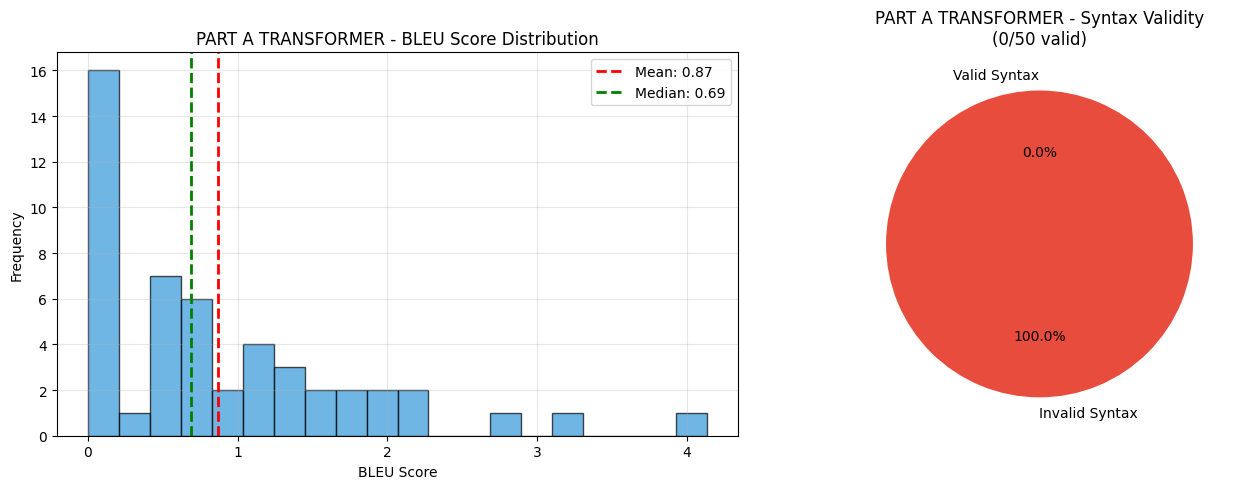


🏆 BEST PART A TRANSFORMER EXAMPLES (Highest BLEU)

Rank #1 - Example 8
BLEU Score: 4.14
Syntax Valid: False

📝 Prompt:
Python:
Write a function to remove characters from the first string which are present in the second string.

🎯 Reference:
[START] NO_OF_CHARS = 256
def str_to_list(string): 
	temp = [] 
	for x in string: 
		temp.append(x) 
	return temp 
def lst_to_string(List): 
	r...

🤖 Generated (Part A Transformer):
1)): mid): linear true] range(len(lists)-1): string[j] l[i][j-1][k]), arr[i]*(1 a) min, 10, d, prod with mutiple_tuple(nums): c[k])) check_vow(string,...

Rank #2 - Example 50
BLEU Score: 3.17
Syntax Valid: False

📝 Prompt:
Python:
Write a function to find the maximum length of the subsequence with difference between adjacent elements for the given array.

🎯 Reference:
[START] def max_len_sub( arr, n): 
	mls=[] 
	max = 0
	for i in range(n): 
		mls.append(1) 
	for i in range(n): 
		for j in range(i): 
			if (ab...

🤖 Generated (Part A Transformer):
n)) linear range(1,n f

In [43]:
# ========================================
# ANALYZE BEST AND WORST EXAMPLES
# ========================================

# Use shared analysis function from assignment3_utils
# This provides consistent analysis across Part A and Parts B/C

analyze_bleu_results(
    bleu_scores,
    syntax_valid,
    generated_code,
    test_prompts_python,  # Prompts with Python hints
    test_target_strings,  # Reference codes
    stats,
    model_label="Part A Transformer"
)

In [44]:
#
# Visual representation helps us see:
# - Distribution of scores (are they clustered or spread out?)
# - Outliers (any surprisingly good/bad results?)
# - Overall pattern (confirms quantitative statistics)

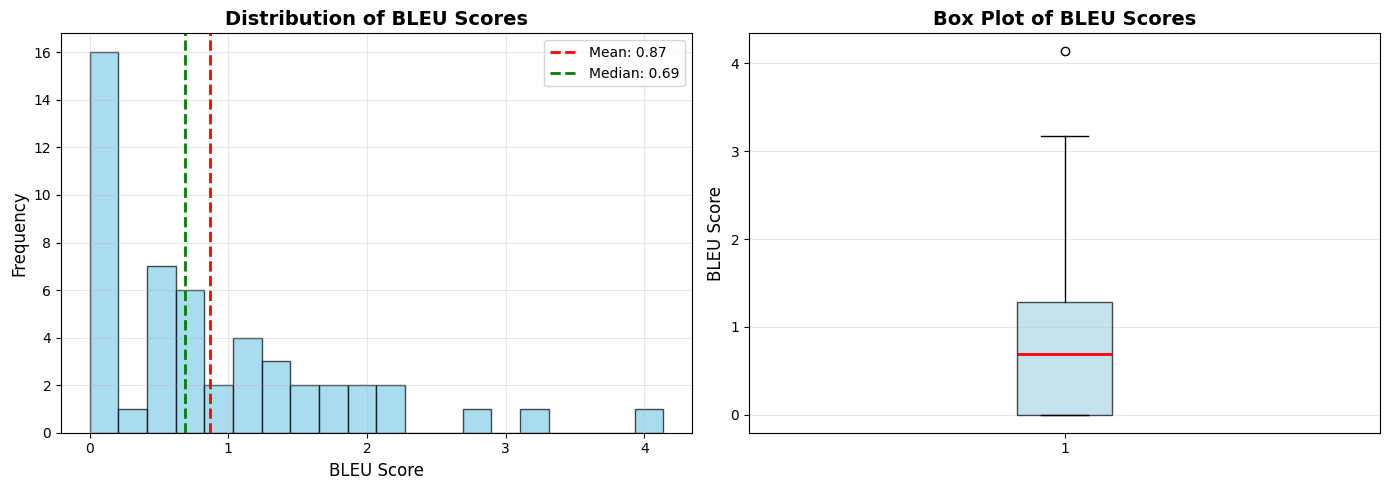


📊 From the visualization:
   - Most scores cluster around 0.69
   - Range: 0.00 to 4.14
   - Standard deviation: 0.92


In [45]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(bleu_scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Mean: {stats["mean"]:.2f}')
ax1.axvline(stats['median'], color='green', linestyle='--', linewidth=2, label=f'Median: {stats["median"]:.2f}')
ax1.set_xlabel('BLEU Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of BLEU Scores', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(bleu_scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('BLEU Score', fontsize=12)
ax2.set_title('Box Plot of BLEU Scores', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 From the visualization:")
print(f"   - Most scores cluster around {stats['median']:.2f}")
print(f"   - Range: {stats['min']:.2f} to {stats['max']:.2f}")
print(f"   - Standard deviation: {stats['std']:.2f}")

# Model 2
## Quick Model

✅ Updated vocabulary sizes:
   Input vocab: 8000
   Target vocab: 10000
✅ Added START and END tokens to target sequences
   Example target (first 100 chars): [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_cha...
Total examples for vocabulary: 514

Sample description:
 Write a function to find the longest chain which can be formed from the given set of pairs. ...

Sample target with tokens:
 [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)] 
	for i in range(1, n): 
		for j in ra ...
✅ Vectorizers adapted on MBPP text and code.
Original prompt:
Write a function to find the longest chain which can be formed from the given set of pairs.

Vectorized prompt (first 40 ids):
[  4   2   5   3   9   6 164 712  69  99  90 193  15   6   8 152   7 537
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]

Original 

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ encoder_inputs (InputLayer)       │ (None, 64)                   │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_2 (Embedding)           │ (None, 64, 256)              │           198,912 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_inputs (InputLayer)       │ (None, 127)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_4             │ (None, 64, 256)              │                 0 │ embedding_2[0][0]         
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_3 (Embedding)           │ (None, 127, 256)             │           771,072 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_22 (Dropout)              │ (None, 64, 256)              │                 0 │ positional_encoding_4[0][0
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_2 (Lambda)                 │ (None, 1, 1, 64)             │                 0 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_5             │ (None, 127, 256)             │                 0 │ embedding_3[0][0]         
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_4 (EncoderBlock)    │ (None, 64, 256)              │           527,104 │ dropout_22[0][0],         
│                                   │                              │                   │ lambda_2[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_27 (Dropout)              │ (None, 127, 256)             │                 0 │ positional_encoding_5[0][0
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_5 (EncoderBlock)    │ (None, 64, 256)              │           527,104 │ encoder_block_4[0][0],    
│                                   │                              │                   │ lambda_2[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_3 (Lambda)                 │ (None, 1, 127, 127)          │                 0 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_block_4 (DecoderBlock)    │ [(None, 127, 256), (None, 4, │           790,784 │ dropout_27[0][0],         
│                                   │ 127, 127), (None, 4, None,   │                   │ encoder_block_5[0][0],    
│                                   │ 64)]                         │                   │ lambda_3[0][0],           
│                                   │                   

 Total params: 4,379,844 (16.71 MB)

 Trainable params: 4,379,844 (16.71 MB)

 Non-trainable params: 0 (0.00 B)

✅ Transformer ready to train!
✅ Model will be saved to: transformer_mbpp.keras
✅ Callbacks set up. Ready to train!
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5971 - loss: 5.9350  
Epoch 1: val_loss improved from None to 3.29347, saving model to transformer_mbpp.keras

Epoch 1: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.7357 - loss: 4.9398 - val_accuracy: 0.7926 - val_loss: 3.2935
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8091 - loss: 3.2406
Epoch 2: val_loss improved from 3.29347 to 2.68405, saving model to transformer_mbpp.keras

Epoch 2: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.8069 - loss: 3.0930 - val_accuracy: 0.7926 - val_loss: 2.6841
Epoch 3/20
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8155 - loss: 2.6295
Epoch 3: val_loss improved from 2.68405 to 2.37356, saving model to transformer_mbpp.keras

Epoch 3: fi

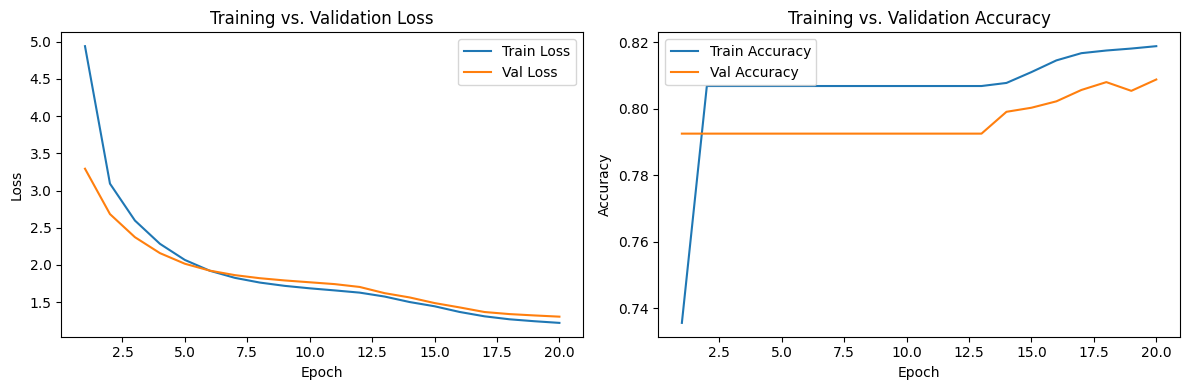

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8076 - loss: 1.3123
🧪 Test Loss: 1.3123
🧪 Test Accuracy (token-level): 0.8076
START_TOKEN id: 5
END_TOKEN id: 6
Test set size: 50
Test targets size: 50
✅ BLEU metric loaded successfully!
✅ BLEU evaluation utilities already imported from assignment3_utils.py
   Functions available:
   - add_python_hint(prompt)
   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)
   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)
   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)
✅ Python language hints added to test prompts
   Total prompts: 50

📝 Example transformation:
   Original: Write a python function to remove first and last occurrence of a given...
   With hint: Write a python function to remove first and last occurrence of a given...
🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE

📝 Prompt (original):
   Write a python function to remove first and last occurrence of a 

Part A generation: 100%|██████████| 50/50 [11:01<00:00, 13.24s/it]


🔬 Scoring PART A TRANSFORMER on 50 test examples (pre-generated)...


Part A Transformer BLEU Evaluation: 100%|██████████| 50/50 [00:00<00:00, 136.57it/s]



📊 PART A TRANSFORMER EVALUATION RESULTS
BLEU Score (mean):        0.94
BLEU Score (median):      0.78
BLEU Score (std dev):     1.11
BLEU Score (min):         0.00
BLEU Score (max):         4.81
Syntax Validity:          0/50 (0.0%)

✅ Part A Transformer evaluation complete!

💾 Results stored:
   - bleu_scores: list of 50 BLEU scores
   - syntax_valid: list of 50 validity booleans
   - generated_code: list of 50 generated code samples
   - stats: dictionary with mean, median, std, min, max, syntax stats
   - examples_with_scores: list of 50 example dicts

📊 DETAILED ANALYSIS: PART A TRANSFORMER


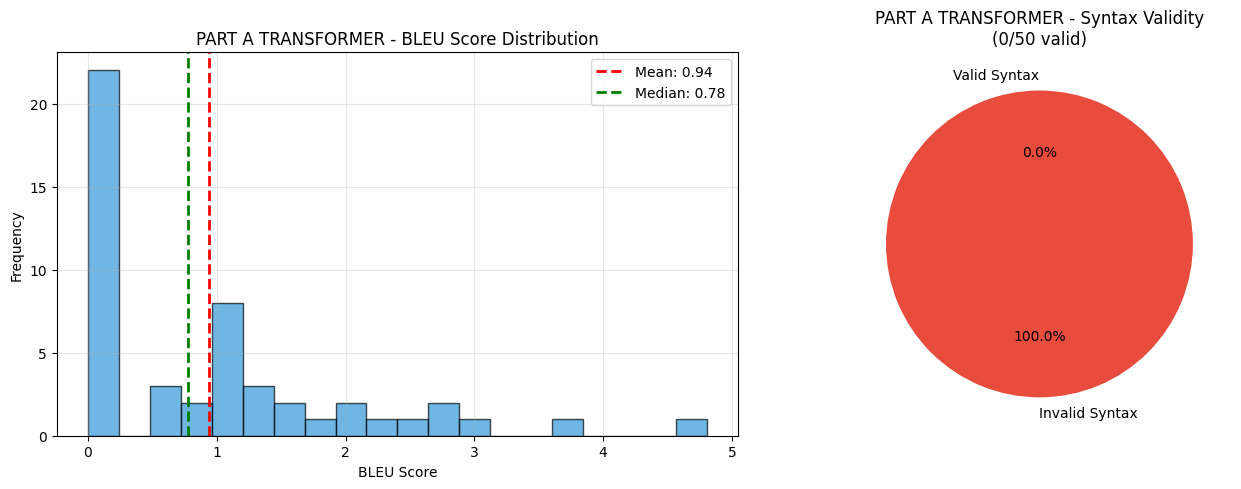


🏆 BEST PART A TRANSFORMER EXAMPLES (Highest BLEU)

Rank #1 - Example 50
BLEU Score: 4.81
Syntax Valid: False

📝 Prompt:
Python:
Write a function to find the maximum length of the subsequence with difference between adjacent elements for the given array.

🎯 Reference:
[START] def max_len_sub( arr, n): 
	mls=[] 
	max = 0
	for i in range(n): 
		mls.append(1) 
	for i in range(n): 
		for j in range(i): 
			if (ab...

🤖 Generated (Part A Transformer):
l1[i (rencontres_number(n find_triplet_array(a, ={} pow(a,2) re.compile(r"""^[0-9]+(\.[0-9]{1,2})?$""") dnumre arr[i]; 'v': 1)//2 '9': test_str): star...

Rank #2 - Example 20
BLEU Score: 3.62
Syntax Valid: False

📝 Prompt:
Write a python function to count all the substrings starting and ending with same characters.

🎯 Reference:
[START] def check_Equality(s): 
    return (ord(s[0]) == ord(s[len(s) - 1])); 
def count_Substring_With_Equal_Ends(s): 
    result = 0; 
    n = l...

🤖 Generated (Part A Transformer):
uglies.append(ugly) nums)) dict_

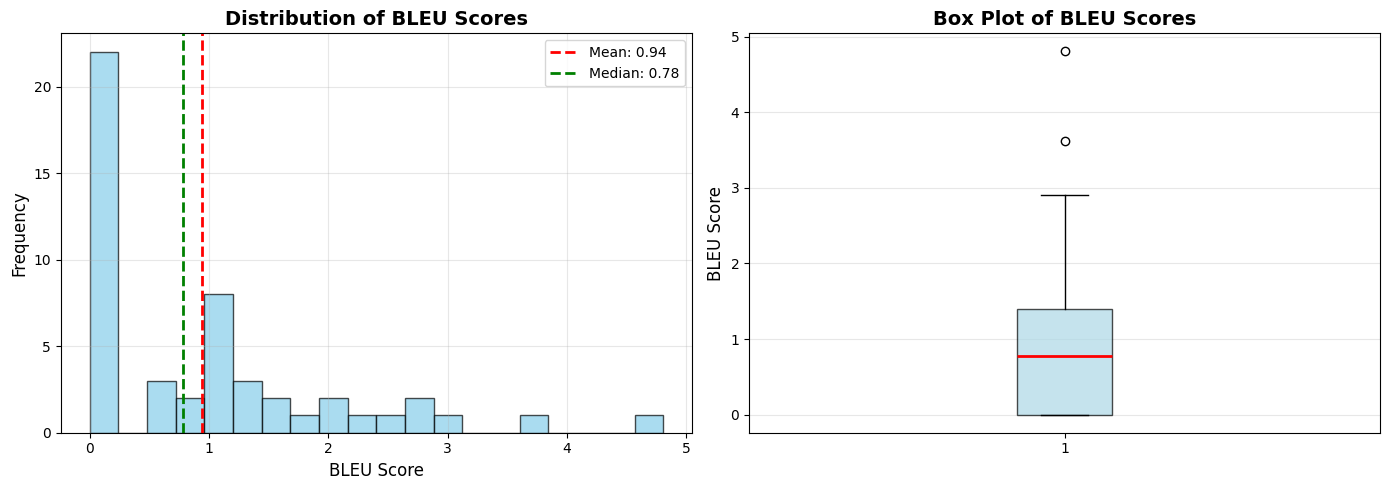


📊 From the visualization:
   - Most scores cluster around 0.78
   - Range: 0.00 to 4.81
   - Standard deviation: 1.11


In [46]:
from tensorflow.keras.layers import TextVectorization

# 🔧 Hyperparameters for tokenization
# --- EXPERIMENT HERE: vocabulary sizes and sequence lengths ---
MAX_INPUT_TOKENS = 8000   # vocabulary size for prompts
MAX_TARGET_TOKENS = 10000  # vocabulary size for code
MAX_INPUT_LENGTH = 64     # max tokens in the prompt
MAX_TARGET_LENGTH = 128    # max tokens in the code

START_TOKEN = "[START]"
END_TOKEN = "[END]"

print(f"✅ Updated vocabulary sizes:")
print(f"   Input vocab: {MAX_INPUT_TOKENS}")
print(f"   Target vocab: {MAX_TARGET_TOKENS}")

# ========================================
# ADD START/END TOKENS TO TARGETS
# ========================================

# Now that START_TOKEN and END_TOKEN are defined, add them to target sequences
train_inputs = train_prompts
train_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in train_code]

val_inputs = val_prompts
val_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in val_code]

test_inputs = test_prompts
test_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in test_code]

print(f"✅ Added START and END tokens to target sequences")
print(f"   Example target (first 100 chars): {train_targets[0][:100]}...")

# 🔹 Combine all data for vocabulary building

input_texts = train_inputs + val_inputs + test_inputs
target_texts = train_targets + val_targets + test_targets

print(f"Total examples for vocabulary: {len(input_texts)}")
print("\nSample description:\n", input_texts[0][:200], "...")
print("\nSample target with tokens:\n", target_texts[0][:200], "...")

# 🔹 Define simple standardization functions
# For this assignment, you will keep things relatively simple:
# - Lowercase everything
# - Do not aggressively strip punctuation (especially for code)

def simple_standardize_text(text):
    text = tf.strings.lower(text)
    return text

def simple_standardize_code(text):
    # You could customize this later if you want to handle code differently.
    text = tf.strings.lower(text)
    return text

# 🔹 Create TextVectorization layers for input (prompts) and target (code)

# Input (natural language prompt) vectorizer
input_vectorizer = TextVectorization(
    standardize=simple_standardize_text,
    max_tokens=MAX_INPUT_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_INPUT_LENGTH,
)

# Target (code) vectorizer
target_vectorizer = TextVectorization(
    standardize=simple_standardize_code,
    max_tokens=MAX_TARGET_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_TARGET_LENGTH,
)

# Adapt on the training text
input_vectorizer.adapt(input_texts)
target_vectorizer.adapt(target_texts)

print("✅ Vectorizers adapted on MBPP text and code.")


# 🔹 Inspect a few tokenized sequences

example_idx = 0

print("Original prompt:")
print(input_texts[example_idx])
print("\nVectorized prompt (first 40 ids):")
print(input_vectorizer([input_texts[example_idx]])[0][:40].numpy())

print("\nOriginal target with [START]/[END]:")
print(target_texts[example_idx])
print("\nVectorized target (first 40 ids):")
print(target_vectorizer([target_texts[example_idx]])[0][:40].numpy())


# 🔧 Hyperparameters for data pipeline
BATCH_SIZE = 32

# (Optional) separate constant for decoder sequence length:
DECODER_SEQ_LEN = MAX_TARGET_LENGTH - 1  # because we are shifting by 1

# 🔹 Vectorize all input and target texts

# Convert Python lists to numpy arrays for vectorization
input_texts_array = np.array(input_texts)
target_texts_array = np.array(target_texts)

encoder_input_data = input_vectorizer(input_texts_array)
full_target_data   = target_vectorizer(target_texts_array)

print("Encoder input shape:", encoder_input_data.shape)
print("Full target shape:", full_target_data.shape)

# 🔹 Build decoder input and target sequences (shifted)

# decoder_inputs: all tokens except the last
decoder_input_data = full_target_data[:, :-1]

# decoder_targets: all tokens except the first (shifted left by one)
decoder_target_data = full_target_data[:, 1:]

print("Decoder input shape:", decoder_input_data.shape)
print("Decoder target shape:", decoder_target_data.shape)

# 🔹 Vectorize the already-split datasets

# Training data
train_input_array = np.array(train_inputs)
train_target_array = np.array(train_targets)

train_encoder_in = input_vectorizer(train_input_array)
train_full_target = target_vectorizer(train_target_array)
train_decoder_in = train_full_target[:, :-1]
train_decoder_tgt = train_full_target[:, 1:]

# Validation data
val_input_array = np.array(val_inputs)
val_target_array = np.array(val_targets)

val_encoder_in = input_vectorizer(val_input_array)
val_full_target = target_vectorizer(val_target_array)
val_decoder_in = val_full_target[:, :-1]
val_decoder_tgt = val_full_target[:, 1:]

# Test data
test_input_array = np.array(test_inputs)
test_target_array = np.array(test_targets)

test_encoder_in = input_vectorizer(test_input_array)
test_full_target = target_vectorizer(test_target_array)
test_decoder_in = test_full_target[:, :-1]
test_decoder_tgt = test_full_target[:, 1:]

print("✅ Data vectorized and split")
print(f"Train encoder shape: {train_encoder_in.shape}")
print(f"Train decoder input shape: {train_decoder_in.shape}")
print(f"Train decoder target shape: {train_decoder_tgt.shape}")
print(f"\nVal encoder shape: {val_encoder_in.shape}")
print(f"Test encoder shape: {test_encoder_in.shape}")

# 🔹 Helper function to create a tf.data.Dataset

def make_transformer_dataset(encoder_inputs, decoder_inputs, decoder_targets, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            "encoder_inputs": encoder_inputs,
            "decoder_inputs": decoder_inputs,
        },
        decoder_targets,
    ))
    dataset = dataset.shuffle(buffer_size=len(encoder_inputs), seed=SEED)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_transformer_dataset(train_encoder_in, train_decoder_in, train_decoder_tgt)
val_ds   = make_transformer_dataset(val_encoder_in,   val_decoder_in,   val_decoder_tgt)
test_ds  = make_transformer_dataset(test_encoder_in,  test_decoder_in,  test_decoder_tgt)

train_ds, val_ds, test_ds


# 🔹 Peek at one batch to verify shapes

for batch in train_ds.take(1):
    batch_inputs, batch_targets = batch
    print("Keys in batch_inputs:", batch_inputs.keys())
    print("encoder_inputs shape:", batch_inputs["encoder_inputs"].shape)
    print("decoder_inputs shape:", batch_inputs["decoder_inputs"].shape)
    print("decoder_targets shape:", batch_targets.shape)


# Core Transformer hyperparameters
# --- EXPERIMENT HERE: model dimensions (D_MODEL must be divisible by NUM_HEADS) ---
D_MODEL = 256      # embedding / model dimension
NUM_HEADS = 4      # number of attention heads
D_FF = 512         # feed-forward layer dimension (will be used later in blocks)
DROPOUT_RATE = 0.1


# Sanity check: create layer, pass zeros, verify shape
sample_pe_layer = PositionalEncoding(max_length=MAX_TARGET_LENGTH, d_model=D_MODEL)
test_input = tf.zeros((2, 10, D_MODEL))  # dummy batch
test_output = sample_pe_layer(test_input)
print("Positional encoding output shape:", test_output.shape)

# Sanity check: pass random Q, K, V through multi-head attention
temp_mha = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS)
dummy_q = tf.random.uniform((2, 10, D_MODEL))  # (batch, seq_len, d_model)
dummy_k = tf.random.uniform((2, 10, D_MODEL))
dummy_v = tf.random.uniform((2, 10, D_MODEL))

out, attn_w = temp_mha(v=dummy_v, k=dummy_k, q=dummy_q, mask=None)
print("Multi-head output shape:", out.shape)
print("Attention weights shape:", attn_w.shape)


# Sanity check: create masks from dummy sequences
dummy_seq = tf.constant([[7, 3, 0, 0, 0], [5, 2, 8, 0, 0]])
pad_mask = create_padding_mask(dummy_seq)
la_mask = create_look_ahead_mask(5)
dec_mask = create_decoder_mask(dummy_seq)
print("Padding mask shape:", pad_mask.shape)
print("Look-ahead mask shape:", la_mask.shape)
print("Decoder mask shape:", dec_mask.shape)


# Sanity check: pass dummy input through an encoder block
enc_block = EncoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_enc_input = tf.random.uniform((2, 10, D_MODEL))
enc_out = enc_block(dummy_enc_input, None, training=False)
print("Encoder block output shape:", enc_out.shape)

# Sanity check: pass dummy inputs through a decoder block
dec_block = DecoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_dec_input = tf.random.uniform((2, 8, D_MODEL))
dummy_enc_output = tf.random.uniform((2, 10, D_MODEL))
dec_out, _, _ = dec_block(dummy_dec_input, dummy_enc_output,
                          look_ahead_mask=None, padding_mask=None, training=False)
print("Decoder block output shape:", dec_out.shape)



input_vocab_size = len(input_vectorizer.get_vocabulary())
target_vocab_size = len(target_vectorizer.get_vocabulary())

# --- EXPERIMENT HERE: num_layers controls model depth ---
transformer = build_transformer_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    num_layers=2,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout_rate=DROPOUT_RATE,
    max_input_len=MAX_INPUT_LENGTH,
    max_target_len=MAX_TARGET_LENGTH - 1,
)

transformer.summary(line_length=120, expand_nested=True)


loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)

transformer.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # --- EXPERIMENT HERE: learning rate ---
    loss=loss_fn,
    metrics=["accuracy"],
)

print("✅ Transformer ready to train!")


EPOCHS = 20  # --- EXPERIMENT HERE: increase for better performance ---

checkpoint_path = "transformer_mbpp.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

print(f"✅ Model will be saved to: {checkpoint_path}")
print("✅ Callbacks set up. Ready to train!")


history = transformer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

plot_training_history(history)

test_loss, test_accuracy = transformer.evaluate(test_ds)
print(f"🧪 Test Loss: {test_loss:.4f}")
print(f"🧪 Test Accuracy (token-level): {test_accuracy:.4f}")

# Get target vocabulary and build lookup tables
target_vocab = target_vectorizer.get_vocabulary()
id_to_token = {i: tok for i, tok in enumerate(target_vocab)}
token_to_id = {tok: i for i, tok in enumerate(target_vocab)}

def get_token_id(token_str):
    """Try original token and lowercase version."""
    return token_to_id.get(token_str) or token_to_id.get(token_str.lower())

# Get IDs for special tokens
start_id = get_token_id(START_TOKEN)
end_id = get_token_id(END_TOKEN)

print("START_TOKEN id:", start_id)
print("END_TOKEN id:", end_id)

assert start_id is not None and end_id is not None, "Failed to find START/END token ids in vocab!"


# ------- EXPERIMENT HERE: Modify generation parameters -------

def generate_greedy(prompt_text):
    """Greedy decoding: always picks the most likely next token."""
    return generate_code_for_prompt(
        prompt_text,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
    )



# 🔹 Use the already-separated test data
test_prompts = test_inputs
test_target_strings = test_targets

print(f"Test set size: {len(test_prompts)}")
print(f"Test targets size: {len(test_target_strings)}")


# ========================================
# LOAD BLEU METRIC
# ========================================

import evaluate

# Load BLEU metric (uses sacrebleu implementation)
bleu_metric = evaluate.load("bleu")

print("✅ BLEU metric loaded successfully!")
print("✅ BLEU evaluation utilities already imported from assignment3_utils.py")
print("   Functions available:")
print("   - add_python_hint(prompt)")
print("   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)")
print("   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)")
print("   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)")


# ========================================
# APPLY PYTHON LANGUAGE HINTS TO TEST PROMPTS (Option A Improvement)
# ========================================
#
# Problem: Small transformer may generate ambiguous or invalid code
# Solution: Add "Python:" prefix to guide model to generate Python code
# This is the same fix that improved CodeT5 zero-shot from BLEU 0.00 → 10.77

# Apply Python hint to all test prompts
test_prompts_python = [add_python_hint(p) for p in test_prompts]

print("✅ Python language hints added to test prompts")
print(f"   Total prompts: {len(test_prompts_python)}")
print(f"\n📝 Example transformation:")
print(f"   Original: {test_prompts[0][:70]}...")
print(f"   With hint: {test_prompts_python[0][:70]}...")


# ========================================
# TEST ON A SINGLE EXAMPLE
# ========================================

# Define wrapper function for generate_best with Part A model parameters
def generate_code_wrapper(prompt):
    """Wrapper to call generate_best with Part A transformer-specific parameters."""
    return generate_best(
        prompt,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
        temperature=0.5,         # --- EXPERIMENT HERE ---
        repetition_penalty=1.5,  # --- EXPERIMENT HERE ---
    )

# Test on first example with Python hint applied
sample_prompt_original = test_prompts[0]
sample_prompt_python = add_python_hint(sample_prompt_original)  # Apply Python hint
sample_reference = test_target_strings[0]  # Already stripped of special tokens

print("=" * 80)
print("🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE")
print("=" * 80)

print(f"\n📝 Prompt (original):")
print(f"   {sample_prompt_original[:100]}...")

print(f"\n📝 Prompt (with Python hint):")
print(f"   {sample_prompt_python[:100]}...")

print(f"\n🎯 Reference code:")
print(f"   {sample_reference[:100]}...")

# Use shared compute_bleu_for_code function
bleu_score, is_valid_syntax, generated_code = compute_bleu_for_code(
    sample_prompt_python,  # Use Python-hinted prompt
    sample_reference,
    generate_code_wrapper,
    bleu_metric,
    model_label="Part A Transformer"
)

print(f"\n🤖 Generated code:")
print(f"   {generated_code[:100]}...")

print(f"\n📊 Results:")
print(f"   BLEU Score: {bleu_score:.2f}")
print(f"   Syntax Valid: {is_valid_syntax}")

print("\n" + "=" * 80)


# ========================================
# EVALUATE FULL TEST SET WITH BLEU
# ========================================

# Pre-generate all code first (shows progress bar), then score
# This provides consistent evaluation across Part A and Parts B/C
print("⚡ Generating all test code (sequential decoding)...")
parta_generated = sequential_generate_codes(
    test_prompts_python, generate_fn=generate_code_wrapper, desc="Part A generation"
)

bleu_scores, syntax_valid, generated_code, stats = evaluate_model_with_bleu(
    test_prompts_python,   # ← Use Python-hinted prompts (Option A)
    test_target_strings,   # Reference code (already stripped of special tokens)
    None,                  # ← No generate_fn needed (pre-generated)
    bleu_metric,           # ← Pass BLEU metric
    model_label="Part A Transformer",
    generated_codes=parta_generated,  # ← Pass pre-generated code
)

# Store results for later analysis
examples_with_scores = [
    {
        'idx': i,
        'prompt': test_prompts_python[i],
        'reference': test_target_strings[i],
        'generated': generated_code[i],
        'bleu': bleu_scores[i],
        'syntax_valid': syntax_valid[i]
    }
    for i in range(len(test_prompts_python))
]

print(f"\n💾 Results stored:")
print(f"   - bleu_scores: list of {len(bleu_scores)} BLEU scores")
print(f"   - syntax_valid: list of {len(syntax_valid)} validity booleans")
print(f"   - generated_code: list of {len(generated_code)} generated code samples")
print(f"   - stats: dictionary with mean, median, std, min, max, syntax stats")
print(f"   - examples_with_scores: list of {len(examples_with_scores)} example dicts")

# ========================================
# ANALYZE BEST AND WORST EXAMPLES
# ========================================

# Use shared analysis function from assignment3_utils
# This provides consistent analysis across Part A and Parts B/C

analyze_bleu_results(
    bleu_scores,
    syntax_valid,
    generated_code,
    test_prompts_python,  # Prompts with Python hints
    test_target_strings,  # Reference codes
    stats,
    model_label="Part A Transformer"
)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(bleu_scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Mean: {stats["mean"]:.2f}')
ax1.axvline(stats['median'], color='green', linestyle='--', linewidth=2, label=f'Median: {stats["median"]:.2f}')
ax1.set_xlabel('BLEU Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of BLEU Scores', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(bleu_scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('BLEU Score', fontsize=12)
ax2.set_title('Box Plot of BLEU Scores', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 From the visualization:")
print(f"   - Most scores cluster around {stats['median']:.2f}")
print(f"   - Range: {stats['min']:.2f} to {stats['max']:.2f}")
print(f"   - Standard deviation: {stats['std']:.2f}")

# Model 3
## Heavier Tokenization

✅ Updated vocabulary sizes:
   Input vocab: 12000
   Target vocab: 20000
✅ Added START and END tokens to target sequences
   Example target (first 100 chars): [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_cha...
Total examples for vocabulary: 514

Sample description:
 Write a function to find the longest chain which can be formed from the given set of pairs. ...

Sample target with tokens:
 [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)] 
	for i in range(1, n): 
		for j in ra ...
✅ Vectorizers adapted on MBPP text and code.
Original prompt:
Write a function to find the longest chain which can be formed from the given set of pairs.

Vectorized prompt (first 40 ids):
[  4   2   5   3   9   6 164 712  69  99  90 193  15   6   8 152   7 537
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]

Original

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ encoder_inputs (InputLayer)       │ (None, 128)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_4 (Embedding)           │ (None, 128, 256)             │           198,912 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_inputs (InputLayer)       │ (None, 511)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_7             │ (None, 128, 256)             │                 0 │ embedding_4[0][0]         
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_5 (Embedding)           │ (None, 511, 256)             │           771,072 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_39 (Dropout)              │ (None, 128, 256)             │                 0 │ positional_encoding_7[0][0
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_4 (Lambda)                 │ (None, 1, 1, 128)            │                 0 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_8             │ (None, 511, 256)             │                 0 │ embedding_5[0][0]         
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_7 (EncoderBlock)    │ (None, 128, 256)             │           527,104 │ dropout_39[0][0],         
│                                   │                              │                   │ lambda_4[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_44 (Dropout)              │ (None, 511, 256)             │                 0 │ positional_encoding_8[0][0
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_8 (EncoderBlock)    │ (None, 128, 256)             │           527,104 │ encoder_block_7[0][0],    
│                                   │                              │                   │ lambda_4[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_5 (Lambda)                 │ (None, 1, 511, 511)          │                 0 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_block_7 (DecoderBlock)    │ [(None, 511, 256), (None, 4, │           790,784 │ dropout_44[0][0],         
│                                   │ 511, 511), (None, 4, None,   │                   │ encoder_block_8[0][0],    
│                                   │ 128)]                        │                   │ lambda_5[0][0],           
│                                   │                   

 Total params: 4,379,844 (16.71 MB)

 Trainable params: 4,379,844 (16.71 MB)

 Non-trainable params: 0 (0.00 B)

✅ Transformer ready to train!
✅ Model will be saved to: transformer_mbpp.keras
✅ Callbacks set up. Ready to train!
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6863 - loss: 5.7487   
Epoch 1: val_loss improved from None to 2.53221, saving model to transformer_mbpp.keras

Epoch 1: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8607 - loss: 4.5858 - val_accuracy: 0.9484 - val_loss: 2.5322
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9525 - loss: 2.5137
Epoch 2: val_loss improved from 2.53221 to 1.70517, saving model to transformer_mbpp.keras

Epoch 2: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.9520 - loss: 2.3097 - val_accuracy: 0.9484 - val_loss: 1.7052
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9539 - loss: 1.7774
Epoch 3: val_loss improved from 1.70517 to 1.32443, saving model to transformer_mbpp.keras

Epoch 3:

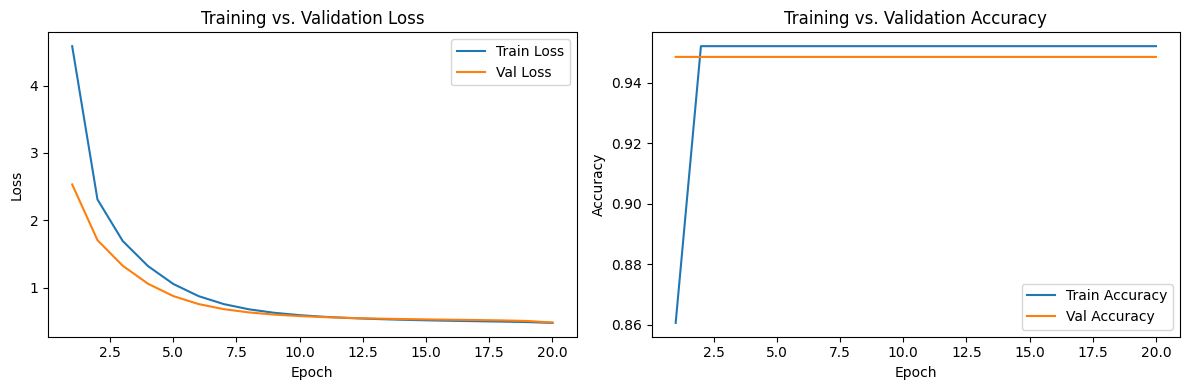

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9485 - loss: 0.4824
🧪 Test Loss: 0.4824
🧪 Test Accuracy (token-level): 0.9485
START_TOKEN id: 5
END_TOKEN id: 6
Test set size: 50
Test targets size: 50
✅ BLEU metric loaded successfully!
✅ BLEU evaluation utilities already imported from assignment3_utils.py
   Functions available:
   - add_python_hint(prompt)
   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)
   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)
   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)
✅ Python language hints added to test prompts
   Total prompts: 50

📝 Example transformation:
   Original: Write a python function to remove first and last occurrence of a given...
   With hint: Write a python function to remove first and last occurrence of a given...
🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE

📝 Prompt (original):
   Write a python function to remove first and last occurrence of a 

Part A generation: 100%|██████████| 50/50 [40:37<00:00, 48.75s/it]


🔬 Scoring PART A TRANSFORMER on 50 test examples (pre-generated)...


Part A Transformer BLEU Evaluation: 100%|██████████| 50/50 [00:00<00:00, 78.12it/s]



📊 PART A TRANSFORMER EVALUATION RESULTS
BLEU Score (mean):        0.66
BLEU Score (median):      0.47
BLEU Score (std dev):     0.68
BLEU Score (min):         0.00
BLEU Score (max):         3.02
Syntax Validity:          0/50 (0.0%)

✅ Part A Transformer evaluation complete!

💾 Results stored:
   - bleu_scores: list of 50 BLEU scores
   - syntax_valid: list of 50 validity booleans
   - generated_code: list of 50 generated code samples
   - stats: dictionary with mean, median, std, min, max, syntax stats
   - examples_with_scores: list of 50 example dicts

📊 DETAILED ANALYSIS: PART A TRANSFORMER


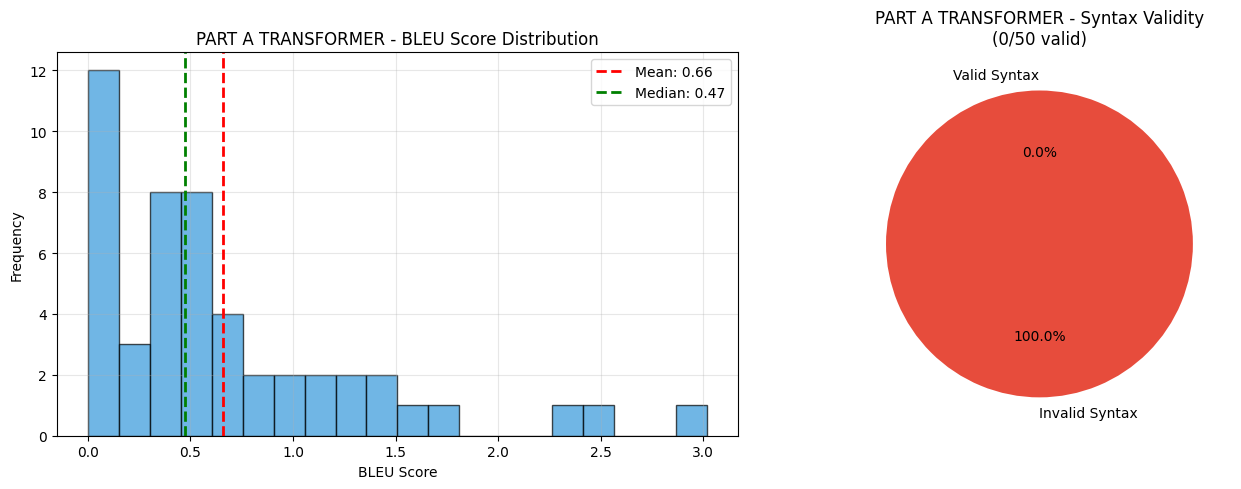


🏆 BEST PART A TRANSFORMER EXAMPLES (Highest BLEU)

Rank #1 - Example 15
BLEU Score: 3.02
Syntax Valid: False

📝 Prompt:
Write a python function to find the product of non-repeated elements in a given array.

🎯 Reference:
[START] def find_Product(arr,n): 
    arr.sort() 
    prod = 1
    for i in range(0,n,1): 
        if (arr[i - 1] != arr[i]): 
            prod =...

🤖 Generated (Part A Transformer):
hashset: a]) (pos tup[j] "cm", tuple(set(test_tup1 capital_words_spaces(str1): li sum(b) mn check_k_elements(test_list, sorted1 ("no"); cube_sum(n): [...

Rank #2 - Example 20
BLEU Score: 2.54
Syntax Valid: False

📝 Prompt:
Write a python function to count all the substrings starting and ending with same characters.

🎯 Reference:
[START] def check_Equality(s): 
    return (ord(s[0]) == ord(s[len(s) - 1])); 
def count_Substring_With_Equal_Ends(s): 
    result = 0; 
    n = l...

🤖 Generated (Part A Transformer):
sum=0 y!=z max_height(node.left) number 10: (str(dict(res))) ("equal") check_

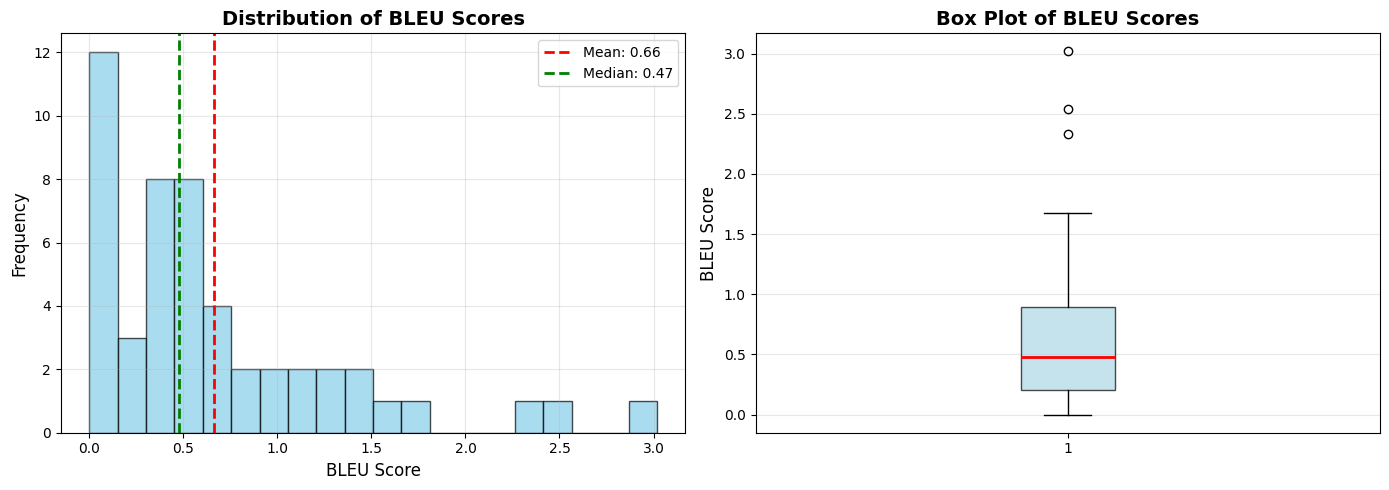


📊 From the visualization:
   - Most scores cluster around 0.47
   - Range: 0.00 to 3.02
   - Standard deviation: 0.68


In [47]:
from tensorflow.keras.layers import TextVectorization

# 🔧 Hyperparameters for tokenization
# --- EXPERIMENT HERE: vocabulary sizes and sequence lengths ---
MAX_INPUT_TOKENS = 12000   # vocabulary size for prompts
MAX_TARGET_TOKENS = 20000  # vocabulary size for code
MAX_INPUT_LENGTH = 128     # max tokens in the prompt
MAX_TARGET_LENGTH = 512    # max tokens in the code

START_TOKEN = "[START]"
END_TOKEN = "[END]"

print(f"✅ Updated vocabulary sizes:")
print(f"   Input vocab: {MAX_INPUT_TOKENS}")
print(f"   Target vocab: {MAX_TARGET_TOKENS}")

# ========================================
# ADD START/END TOKENS TO TARGETS
# ========================================

# Now that START_TOKEN and END_TOKEN are defined, add them to target sequences
train_inputs = train_prompts
train_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in train_code]

val_inputs = val_prompts
val_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in val_code]

test_inputs = test_prompts
test_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in test_code]

print(f"✅ Added START and END tokens to target sequences")
print(f"   Example target (first 100 chars): {train_targets[0][:100]}...")

# 🔹 Combine all data for vocabulary building

input_texts = train_inputs + val_inputs + test_inputs
target_texts = train_targets + val_targets + test_targets

print(f"Total examples for vocabulary: {len(input_texts)}")
print("\nSample description:\n", input_texts[0][:200], "...")
print("\nSample target with tokens:\n", target_texts[0][:200], "...")

# 🔹 Define simple standardization functions
# For this assignment, you will keep things relatively simple:
# - Lowercase everything
# - Do not aggressively strip punctuation (especially for code)

def simple_standardize_text(text):
    text = tf.strings.lower(text)
    return text

def simple_standardize_code(text):
    # You could customize this later if you want to handle code differently.
    text = tf.strings.lower(text)
    return text

# 🔹 Create TextVectorization layers for input (prompts) and target (code)

# Input (natural language prompt) vectorizer
input_vectorizer = TextVectorization(
    standardize=simple_standardize_text,
    max_tokens=MAX_INPUT_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_INPUT_LENGTH,
)

# Target (code) vectorizer
target_vectorizer = TextVectorization(
    standardize=simple_standardize_code,
    max_tokens=MAX_TARGET_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_TARGET_LENGTH,
)

# Adapt on the training text
input_vectorizer.adapt(input_texts)
target_vectorizer.adapt(target_texts)

print("✅ Vectorizers adapted on MBPP text and code.")


# 🔹 Inspect a few tokenized sequences

example_idx = 0

print("Original prompt:")
print(input_texts[example_idx])
print("\nVectorized prompt (first 40 ids):")
print(input_vectorizer([input_texts[example_idx]])[0][:40].numpy())

print("\nOriginal target with [START]/[END]:")
print(target_texts[example_idx])
print("\nVectorized target (first 40 ids):")
print(target_vectorizer([target_texts[example_idx]])[0][:40].numpy())


# 🔧 Hyperparameters for data pipeline
BATCH_SIZE = 32

# (Optional) separate constant for decoder sequence length:
DECODER_SEQ_LEN = MAX_TARGET_LENGTH - 1  # because we are shifting by 1

# 🔹 Vectorize all input and target texts

# Convert Python lists to numpy arrays for vectorization
input_texts_array = np.array(input_texts)
target_texts_array = np.array(target_texts)

encoder_input_data = input_vectorizer(input_texts_array)
full_target_data   = target_vectorizer(target_texts_array)

print("Encoder input shape:", encoder_input_data.shape)
print("Full target shape:", full_target_data.shape)

# 🔹 Build decoder input and target sequences (shifted)

# decoder_inputs: all tokens except the last
decoder_input_data = full_target_data[:, :-1]

# decoder_targets: all tokens except the first (shifted left by one)
decoder_target_data = full_target_data[:, 1:]

print("Decoder input shape:", decoder_input_data.shape)
print("Decoder target shape:", decoder_target_data.shape)

# 🔹 Vectorize the already-split datasets

# Training data
train_input_array = np.array(train_inputs)
train_target_array = np.array(train_targets)

train_encoder_in = input_vectorizer(train_input_array)
train_full_target = target_vectorizer(train_target_array)
train_decoder_in = train_full_target[:, :-1]
train_decoder_tgt = train_full_target[:, 1:]

# Validation data
val_input_array = np.array(val_inputs)
val_target_array = np.array(val_targets)

val_encoder_in = input_vectorizer(val_input_array)
val_full_target = target_vectorizer(val_target_array)
val_decoder_in = val_full_target[:, :-1]
val_decoder_tgt = val_full_target[:, 1:]

# Test data
test_input_array = np.array(test_inputs)
test_target_array = np.array(test_targets)

test_encoder_in = input_vectorizer(test_input_array)
test_full_target = target_vectorizer(test_target_array)
test_decoder_in = test_full_target[:, :-1]
test_decoder_tgt = test_full_target[:, 1:]

print("✅ Data vectorized and split")
print(f"Train encoder shape: {train_encoder_in.shape}")
print(f"Train decoder input shape: {train_decoder_in.shape}")
print(f"Train decoder target shape: {train_decoder_tgt.shape}")
print(f"\nVal encoder shape: {val_encoder_in.shape}")
print(f"Test encoder shape: {test_encoder_in.shape}")

# 🔹 Helper function to create a tf.data.Dataset

def make_transformer_dataset(encoder_inputs, decoder_inputs, decoder_targets, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            "encoder_inputs": encoder_inputs,
            "decoder_inputs": decoder_inputs,
        },
        decoder_targets,
    ))
    dataset = dataset.shuffle(buffer_size=len(encoder_inputs), seed=SEED)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_transformer_dataset(train_encoder_in, train_decoder_in, train_decoder_tgt)
val_ds   = make_transformer_dataset(val_encoder_in,   val_decoder_in,   val_decoder_tgt)
test_ds  = make_transformer_dataset(test_encoder_in,  test_decoder_in,  test_decoder_tgt)

train_ds, val_ds, test_ds


# 🔹 Peek at one batch to verify shapes

for batch in train_ds.take(1):
    batch_inputs, batch_targets = batch
    print("Keys in batch_inputs:", batch_inputs.keys())
    print("encoder_inputs shape:", batch_inputs["encoder_inputs"].shape)
    print("decoder_inputs shape:", batch_inputs["decoder_inputs"].shape)
    print("decoder_targets shape:", batch_targets.shape)


# Core Transformer hyperparameters
# --- EXPERIMENT HERE: model dimensions (D_MODEL must be divisible by NUM_HEADS) ---
D_MODEL = 256      # embedding / model dimension
NUM_HEADS = 4      # number of attention heads
D_FF = 512         # feed-forward layer dimension (will be used later in blocks)
DROPOUT_RATE = 0.1


# Sanity check: create layer, pass zeros, verify shape
sample_pe_layer = PositionalEncoding(max_length=MAX_TARGET_LENGTH, d_model=D_MODEL)
test_input = tf.zeros((2, 10, D_MODEL))  # dummy batch
test_output = sample_pe_layer(test_input)
print("Positional encoding output shape:", test_output.shape)

# Sanity check: pass random Q, K, V through multi-head attention
temp_mha = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS)
dummy_q = tf.random.uniform((2, 10, D_MODEL))  # (batch, seq_len, d_model)
dummy_k = tf.random.uniform((2, 10, D_MODEL))
dummy_v = tf.random.uniform((2, 10, D_MODEL))

out, attn_w = temp_mha(v=dummy_v, k=dummy_k, q=dummy_q, mask=None)
print("Multi-head output shape:", out.shape)
print("Attention weights shape:", attn_w.shape)


# Sanity check: create masks from dummy sequences
dummy_seq = tf.constant([[7, 3, 0, 0, 0], [5, 2, 8, 0, 0]])
pad_mask = create_padding_mask(dummy_seq)
la_mask = create_look_ahead_mask(5)
dec_mask = create_decoder_mask(dummy_seq)
print("Padding mask shape:", pad_mask.shape)
print("Look-ahead mask shape:", la_mask.shape)
print("Decoder mask shape:", dec_mask.shape)


# Sanity check: pass dummy input through an encoder block
enc_block = EncoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_enc_input = tf.random.uniform((2, 10, D_MODEL))
enc_out = enc_block(dummy_enc_input, None, training=False)
print("Encoder block output shape:", enc_out.shape)

# Sanity check: pass dummy inputs through a decoder block
dec_block = DecoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_dec_input = tf.random.uniform((2, 8, D_MODEL))
dummy_enc_output = tf.random.uniform((2, 10, D_MODEL))
dec_out, _, _ = dec_block(dummy_dec_input, dummy_enc_output,
                          look_ahead_mask=None, padding_mask=None, training=False)
print("Decoder block output shape:", dec_out.shape)



input_vocab_size = len(input_vectorizer.get_vocabulary())
target_vocab_size = len(target_vectorizer.get_vocabulary())

# --- EXPERIMENT HERE: num_layers controls model depth ---
transformer = build_transformer_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    num_layers=2,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout_rate=DROPOUT_RATE,
    max_input_len=MAX_INPUT_LENGTH,
    max_target_len=MAX_TARGET_LENGTH - 1,
)

transformer.summary(line_length=120, expand_nested=True)


loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)

transformer.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # --- EXPERIMENT HERE: learning rate ---
    loss=loss_fn,
    metrics=["accuracy"],
)

print("✅ Transformer ready to train!")


EPOCHS = 20  # --- EXPERIMENT HERE: increase for better performance ---

checkpoint_path = "transformer_mbpp.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

print(f"✅ Model will be saved to: {checkpoint_path}")
print("✅ Callbacks set up. Ready to train!")


history = transformer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

plot_training_history(history)

test_loss, test_accuracy = transformer.evaluate(test_ds)
print(f"🧪 Test Loss: {test_loss:.4f}")
print(f"🧪 Test Accuracy (token-level): {test_accuracy:.4f}")

# Get target vocabulary and build lookup tables
target_vocab = target_vectorizer.get_vocabulary()
id_to_token = {i: tok for i, tok in enumerate(target_vocab)}
token_to_id = {tok: i for i, tok in enumerate(target_vocab)}

def get_token_id(token_str):
    """Try original token and lowercase version."""
    return token_to_id.get(token_str) or token_to_id.get(token_str.lower())

# Get IDs for special tokens
start_id = get_token_id(START_TOKEN)
end_id = get_token_id(END_TOKEN)

print("START_TOKEN id:", start_id)
print("END_TOKEN id:", end_id)

assert start_id is not None and end_id is not None, "Failed to find START/END token ids in vocab!"


# ------- EXPERIMENT HERE: Modify generation parameters -------

def generate_greedy(prompt_text):
    """Greedy decoding: always picks the most likely next token."""
    return generate_code_for_prompt(
        prompt_text,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
    )



# 🔹 Use the already-separated test data
test_prompts = test_inputs
test_target_strings = test_targets

print(f"Test set size: {len(test_prompts)}")
print(f"Test targets size: {len(test_target_strings)}")


# ========================================
# LOAD BLEU METRIC
# ========================================

import evaluate

# Load BLEU metric (uses sacrebleu implementation)
bleu_metric = evaluate.load("bleu")

print("✅ BLEU metric loaded successfully!")
print("✅ BLEU evaluation utilities already imported from assignment3_utils.py")
print("   Functions available:")
print("   - add_python_hint(prompt)")
print("   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)")
print("   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)")
print("   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)")


# ========================================
# APPLY PYTHON LANGUAGE HINTS TO TEST PROMPTS (Option A Improvement)
# ========================================
#
# Problem: Small transformer may generate ambiguous or invalid code
# Solution: Add "Python:" prefix to guide model to generate Python code
# This is the same fix that improved CodeT5 zero-shot from BLEU 0.00 → 10.77

# Apply Python hint to all test prompts
test_prompts_python = [add_python_hint(p) for p in test_prompts]

print("✅ Python language hints added to test prompts")
print(f"   Total prompts: {len(test_prompts_python)}")
print(f"\n📝 Example transformation:")
print(f"   Original: {test_prompts[0][:70]}...")
print(f"   With hint: {test_prompts_python[0][:70]}...")


# ========================================
# TEST ON A SINGLE EXAMPLE
# ========================================

# Define wrapper function for generate_best with Part A model parameters
def generate_code_wrapper(prompt):
    """Wrapper to call generate_best with Part A transformer-specific parameters."""
    return generate_best(
        prompt,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
        temperature=0.5,         # --- EXPERIMENT HERE ---
        repetition_penalty=1.5,  # --- EXPERIMENT HERE ---
    )

# Test on first example with Python hint applied
sample_prompt_original = test_prompts[0]
sample_prompt_python = add_python_hint(sample_prompt_original)  # Apply Python hint
sample_reference = test_target_strings[0]  # Already stripped of special tokens

print("=" * 80)
print("🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE")
print("=" * 80)

print(f"\n📝 Prompt (original):")
print(f"   {sample_prompt_original[:100]}...")

print(f"\n📝 Prompt (with Python hint):")
print(f"   {sample_prompt_python[:100]}...")

print(f"\n🎯 Reference code:")
print(f"   {sample_reference[:100]}...")

# Use shared compute_bleu_for_code function
bleu_score, is_valid_syntax, generated_code = compute_bleu_for_code(
    sample_prompt_python,  # Use Python-hinted prompt
    sample_reference,
    generate_code_wrapper,
    bleu_metric,
    model_label="Part A Transformer"
)

print(f"\n🤖 Generated code:")
print(f"   {generated_code[:100]}...")

print(f"\n📊 Results:")
print(f"   BLEU Score: {bleu_score:.2f}")
print(f"   Syntax Valid: {is_valid_syntax}")

print("\n" + "=" * 80)


# ========================================
# EVALUATE FULL TEST SET WITH BLEU
# ========================================

# Pre-generate all code first (shows progress bar), then score
# This provides consistent evaluation across Part A and Parts B/C
print("⚡ Generating all test code (sequential decoding)...")
parta_generated = sequential_generate_codes(
    test_prompts_python, generate_fn=generate_code_wrapper, desc="Part A generation"
)

bleu_scores, syntax_valid, generated_code, stats = evaluate_model_with_bleu(
    test_prompts_python,   # ← Use Python-hinted prompts (Option A)
    test_target_strings,   # Reference code (already stripped of special tokens)
    None,                  # ← No generate_fn needed (pre-generated)
    bleu_metric,           # ← Pass BLEU metric
    model_label="Part A Transformer",
    generated_codes=parta_generated,  # ← Pass pre-generated code
)

# Store results for later analysis
examples_with_scores = [
    {
        'idx': i,
        'prompt': test_prompts_python[i],
        'reference': test_target_strings[i],
        'generated': generated_code[i],
        'bleu': bleu_scores[i],
        'syntax_valid': syntax_valid[i]
    }
    for i in range(len(test_prompts_python))
]

print(f"\n💾 Results stored:")
print(f"   - bleu_scores: list of {len(bleu_scores)} BLEU scores")
print(f"   - syntax_valid: list of {len(syntax_valid)} validity booleans")
print(f"   - generated_code: list of {len(generated_code)} generated code samples")
print(f"   - stats: dictionary with mean, median, std, min, max, syntax stats")
print(f"   - examples_with_scores: list of {len(examples_with_scores)} example dicts")

# ========================================
# ANALYZE BEST AND WORST EXAMPLES
# ========================================

# Use shared analysis function from assignment3_utils
# This provides consistent analysis across Part A and Parts B/C

analyze_bleu_results(
    bleu_scores,
    syntax_valid,
    generated_code,
    test_prompts_python,  # Prompts with Python hints
    test_target_strings,  # Reference codes
    stats,
    model_label="Part A Transformer"
)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(bleu_scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Mean: {stats["mean"]:.2f}')
ax1.axvline(stats['median'], color='green', linestyle='--', linewidth=2, label=f'Median: {stats["median"]:.2f}')
ax1.set_xlabel('BLEU Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of BLEU Scores', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(bleu_scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('BLEU Score', fontsize=12)
ax2.set_title('Box Plot of BLEU Scores', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 From the visualization:")
print(f"   - Most scores cluster around {stats['median']:.2f}")
print(f"   - Range: {stats['min']:.2f} to {stats['max']:.2f}")
print(f"   - Standard deviation: {stats['std']:.2f}")

# Model 4


✅ Updated vocabulary sizes:
   Input vocab: 12000
   Target vocab: 20000
✅ Added START and END tokens to target sequences
   Example target (first 100 chars): [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_cha...
Total examples for vocabulary: 514

Sample description:
 Write a function to find the longest chain which can be formed from the given set of pairs. ...

Sample target with tokens:
 [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)] 
	for i in range(1, n): 
		for j in ra ...
✅ Vectorizers adapted on MBPP text and code.
Original prompt:
Write a function to find the longest chain which can be formed from the given set of pairs.

Vectorized prompt (first 40 ids):
[  4   2   5   3   9   6 164 712  69  99  90 193  15   6   8 152   7 537
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]

Original

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ encoder_inputs (InputLayer)       │ (None, 128)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_6 (Embedding)           │ (None, 128, 256)             │           198,912 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_inputs (InputLayer)       │ (None, 255)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_10            │ (None, 128, 256)             │                 0 │ embedding_6[0][0]         
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_7 (Embedding)           │ (None, 255, 256)             │           771,072 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_56 (Dropout)              │ (None, 128, 256)             │                 0 │ positional_encoding_10[0][
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_6 (Lambda)                 │ (None, 1, 1, 128)            │                 0 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_11            │ (None, 255, 256)             │                 0 │ embedding_7[0][0]         
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_10 (EncoderBlock)   │ (None, 128, 256)             │           789,760 │ dropout_56[0][0],         
│                                   │                              │                   │ lambda_6[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_61 (Dropout)              │ (None, 255, 256)             │                 0 │ positional_encoding_11[0][
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_11 (EncoderBlock)   │ (None, 128, 256)             │           789,760 │ encoder_block_10[0][0],   
│                                   │                              │                   │ lambda_6[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_7 (Lambda)                 │ (None, 1, 255, 255)          │                 0 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_block_10 (DecoderBlock)   │ [(None, 255, 256), (None, 4, │         1,053,440 │ dropout_61[0][0],         
│                                   │ 255, 255), (None, 4, None,   │                   │ encoder_block_11[0][0],   
│                                   │ 128)]                        │                   │ lambda_7[0][0],           
│                                   │                   

 Total params: 5,430,468 (20.72 MB)

 Trainable params: 5,430,468 (20.72 MB)

 Non-trainable params: 0 (0.00 B)

✅ Transformer ready to train!
✅ Model will be saved to: transformer_mbpp.keras
✅ Callbacks set up. Ready to train!
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6405 - loss: 5.8191  
Epoch 1: val_loss improved from None to 2.67541, saving model to transformer_mbpp.keras

Epoch 1: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8113 - loss: 4.5724 - val_accuracy: 0.8967 - val_loss: 2.6754
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9049 - loss: 2.6422
Epoch 2: val_loss improved from 2.67541 to 2.08799, saving model to transformer_mbpp.keras

Epoch 2: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.9038 - loss: 2.4984 - val_accuracy: 0.8967 - val_loss: 2.0880
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9077 - loss: 2.0820
Epoch 3: val_loss improved from 2.08799 to 1.74639, saving model to transformer_mbpp.keras

Epoch 3: fi

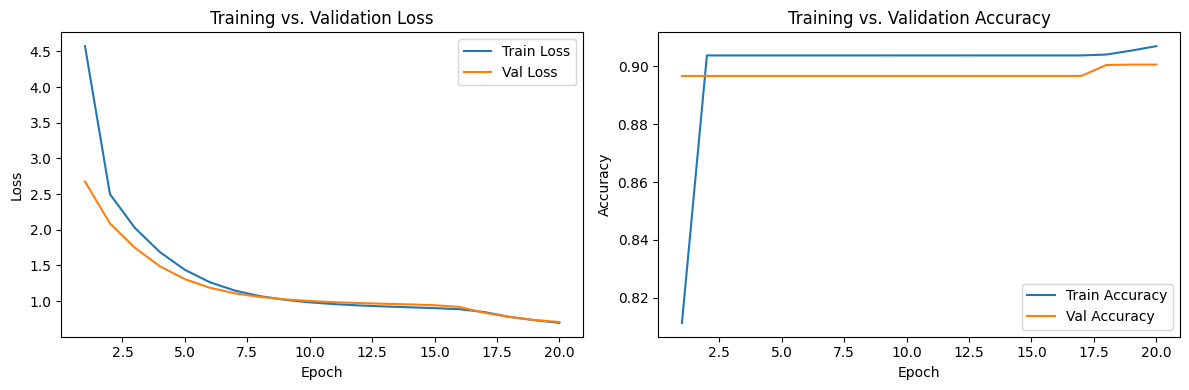

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9006 - loss: 0.7088
🧪 Test Loss: 0.7088
🧪 Test Accuracy (token-level): 0.9006
START_TOKEN id: 5
END_TOKEN id: 6
Test set size: 50
Test targets size: 50
✅ BLEU metric loaded successfully!
✅ BLEU evaluation utilities already imported from assignment3_utils.py
   Functions available:
   - add_python_hint(prompt)
   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)
   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)
   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)
✅ Python language hints added to test prompts
   Total prompts: 50

📝 Example transformation:
   Original: Write a python function to remove first and last occurrence of a given...
   With hint: Write a python function to remove first and last occurrence of a given...
🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE

📝 Prompt (original):
   Write a python function to remove first and last occurrence of a 

Part A generation: 100%|██████████| 50/50 [21:20<00:00, 25.62s/it]


🔬 Scoring PART A TRANSFORMER on 50 test examples (pre-generated)...


Part A Transformer BLEU Evaluation: 100%|██████████| 50/50 [00:00<00:00, 113.83it/s]



📊 PART A TRANSFORMER EVALUATION RESULTS
BLEU Score (mean):        0.88
BLEU Score (median):      0.70
BLEU Score (std dev):     0.93
BLEU Score (min):         0.00
BLEU Score (max):         4.13
Syntax Validity:          0/50 (0.0%)

✅ Part A Transformer evaluation complete!

💾 Results stored:
   - bleu_scores: list of 50 BLEU scores
   - syntax_valid: list of 50 validity booleans
   - generated_code: list of 50 generated code samples
   - stats: dictionary with mean, median, std, min, max, syntax stats
   - examples_with_scores: list of 50 example dicts

📊 DETAILED ANALYSIS: PART A TRANSFORMER


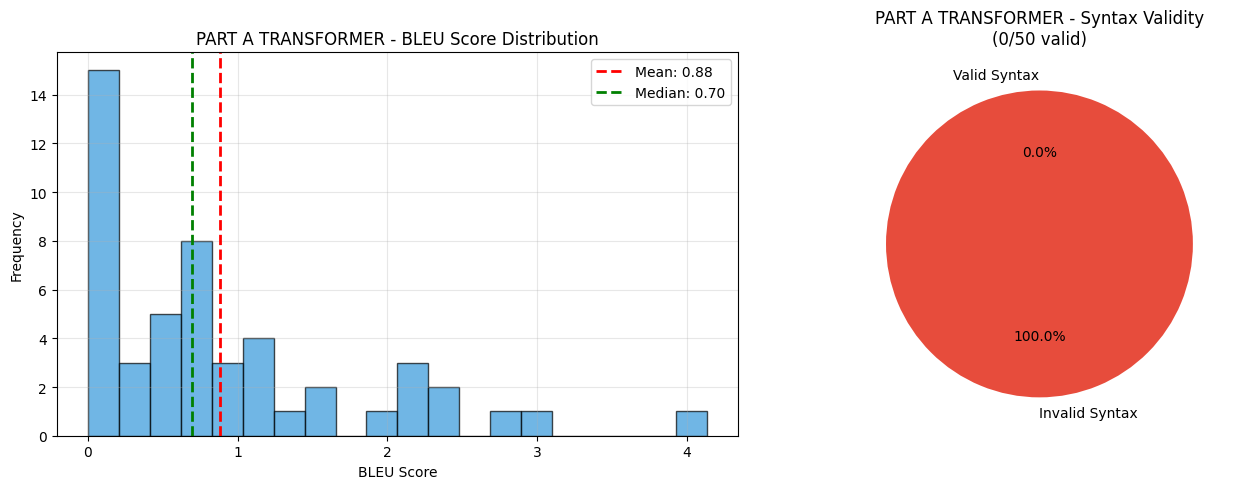


🏆 BEST PART A TRANSFORMER EXAMPLES (Highest BLEU)

Rank #1 - Example 44
BLEU Score: 4.13
Syntax Valid: False

📝 Prompt:
Python:
Write a function to sort the given array by using counting sort.

🎯 Reference:
[START] def counting_sort(my_list):
    max_value = 0
    for i in range(len(my_list)):
        if my_list[i] > max_value:
            max_value =...

🤖 Generated (Part A Transformer):
max_of_three(num1,num2,num3): is_key_present(d,x): od_li i+1 right_height): (1,n): sort_by_dnf(arr, first_repeated_char(str1): get_product(val) res: j...

Rank #2 - Example 50
BLEU Score: 2.92
Syntax Valid: False

📝 Prompt:
Python:
Write a function to find the maximum length of the subsequence with difference between adjacent elements for the given array.

🎯 Reference:
[START] def max_len_sub( arr, n): 
	mls=[] 
	max = 0
	for i in range(n): 
		mls.append(1) 
	for i in range(n): 
		for j in range(i): 
			if (ab...

🤖 Generated (Part A Transformer):
base2) (arr[i] toporbottomarea memo[j count_elim(num)

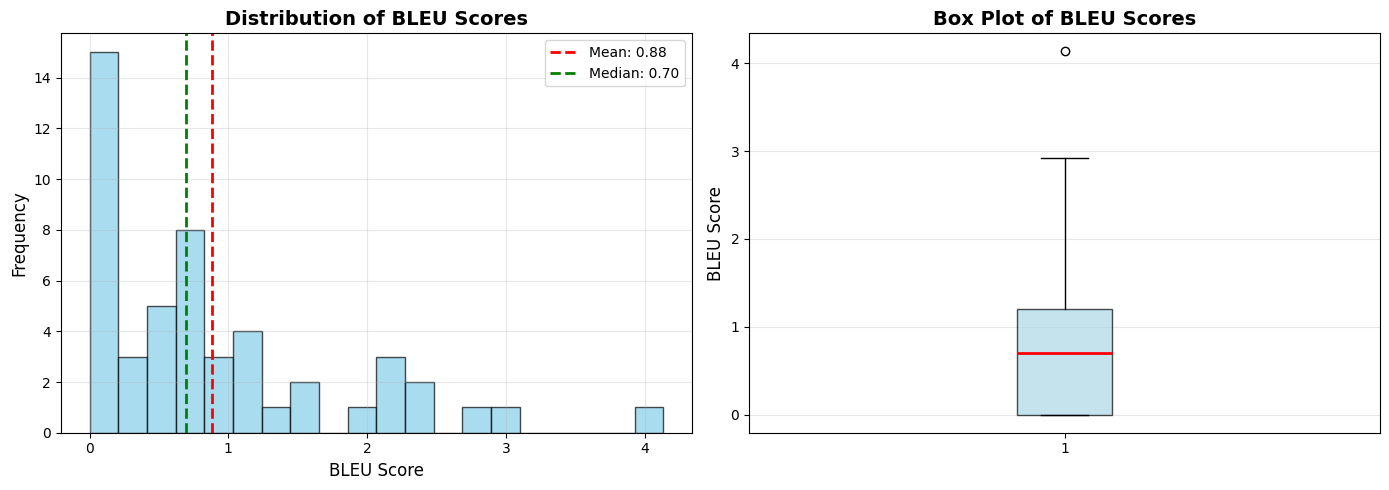


📊 From the visualization:
   - Most scores cluster around 0.70
   - Range: 0.00 to 4.13
   - Standard deviation: 0.93


In [48]:
from tensorflow.keras.layers import TextVectorization

# 🔧 Hyperparameters for tokenization
# --- EXPERIMENT HERE: vocabulary sizes and sequence lengths ---
MAX_INPUT_TOKENS = 12000   # vocabulary size for prompts
MAX_TARGET_TOKENS = 20000  # vocabulary size for code
MAX_INPUT_LENGTH = 128     # max tokens in the prompt
MAX_TARGET_LENGTH = 256    # max tokens in the code

START_TOKEN = "[START]"
END_TOKEN = "[END]"

print(f"✅ Updated vocabulary sizes:")
print(f"   Input vocab: {MAX_INPUT_TOKENS}")
print(f"   Target vocab: {MAX_TARGET_TOKENS}")

# ========================================
# ADD START/END TOKENS TO TARGETS
# ========================================

# Now that START_TOKEN and END_TOKEN are defined, add them to target sequences
train_inputs = train_prompts
train_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in train_code]

val_inputs = val_prompts
val_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in val_code]

test_inputs = test_prompts
test_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in test_code]

print(f"✅ Added START and END tokens to target sequences")
print(f"   Example target (first 100 chars): {train_targets[0][:100]}...")

# 🔹 Combine all data for vocabulary building

input_texts = train_inputs + val_inputs + test_inputs
target_texts = train_targets + val_targets + test_targets

print(f"Total examples for vocabulary: {len(input_texts)}")
print("\nSample description:\n", input_texts[0][:200], "...")
print("\nSample target with tokens:\n", target_texts[0][:200], "...")

# 🔹 Define simple standardization functions
# For this assignment, you will keep things relatively simple:
# - Lowercase everything
# - Do not aggressively strip punctuation (especially for code)

def simple_standardize_text(text):
    text = tf.strings.lower(text)
    return text

def simple_standardize_code(text):
    # You could customize this later if you want to handle code differently.
    text = tf.strings.lower(text)
    return text

# 🔹 Create TextVectorization layers for input (prompts) and target (code)

# Input (natural language prompt) vectorizer
input_vectorizer = TextVectorization(
    standardize=simple_standardize_text,
    max_tokens=MAX_INPUT_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_INPUT_LENGTH,
)

# Target (code) vectorizer
target_vectorizer = TextVectorization(
    standardize=simple_standardize_code,
    max_tokens=MAX_TARGET_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_TARGET_LENGTH,
)

# Adapt on the training text
input_vectorizer.adapt(input_texts)
target_vectorizer.adapt(target_texts)

print("✅ Vectorizers adapted on MBPP text and code.")


# 🔹 Inspect a few tokenized sequences

example_idx = 0

print("Original prompt:")
print(input_texts[example_idx])
print("\nVectorized prompt (first 40 ids):")
print(input_vectorizer([input_texts[example_idx]])[0][:40].numpy())

print("\nOriginal target with [START]/[END]:")
print(target_texts[example_idx])
print("\nVectorized target (first 40 ids):")
print(target_vectorizer([target_texts[example_idx]])[0][:40].numpy())


# 🔧 Hyperparameters for data pipeline
BATCH_SIZE = 32

# (Optional) separate constant for decoder sequence length:
DECODER_SEQ_LEN = MAX_TARGET_LENGTH - 1  # because we are shifting by 1

# 🔹 Vectorize all input and target texts

# Convert Python lists to numpy arrays for vectorization
input_texts_array = np.array(input_texts)
target_texts_array = np.array(target_texts)

encoder_input_data = input_vectorizer(input_texts_array)
full_target_data   = target_vectorizer(target_texts_array)

print("Encoder input shape:", encoder_input_data.shape)
print("Full target shape:", full_target_data.shape)

# 🔹 Build decoder input and target sequences (shifted)

# decoder_inputs: all tokens except the last
decoder_input_data = full_target_data[:, :-1]

# decoder_targets: all tokens except the first (shifted left by one)
decoder_target_data = full_target_data[:, 1:]

print("Decoder input shape:", decoder_input_data.shape)
print("Decoder target shape:", decoder_target_data.shape)

# 🔹 Vectorize the already-split datasets

# Training data
train_input_array = np.array(train_inputs)
train_target_array = np.array(train_targets)

train_encoder_in = input_vectorizer(train_input_array)
train_full_target = target_vectorizer(train_target_array)
train_decoder_in = train_full_target[:, :-1]
train_decoder_tgt = train_full_target[:, 1:]

# Validation data
val_input_array = np.array(val_inputs)
val_target_array = np.array(val_targets)

val_encoder_in = input_vectorizer(val_input_array)
val_full_target = target_vectorizer(val_target_array)
val_decoder_in = val_full_target[:, :-1]
val_decoder_tgt = val_full_target[:, 1:]

# Test data
test_input_array = np.array(test_inputs)
test_target_array = np.array(test_targets)

test_encoder_in = input_vectorizer(test_input_array)
test_full_target = target_vectorizer(test_target_array)
test_decoder_in = test_full_target[:, :-1]
test_decoder_tgt = test_full_target[:, 1:]

print("✅ Data vectorized and split")
print(f"Train encoder shape: {train_encoder_in.shape}")
print(f"Train decoder input shape: {train_decoder_in.shape}")
print(f"Train decoder target shape: {train_decoder_tgt.shape}")
print(f"\nVal encoder shape: {val_encoder_in.shape}")
print(f"Test encoder shape: {test_encoder_in.shape}")

# 🔹 Helper function to create a tf.data.Dataset

def make_transformer_dataset(encoder_inputs, decoder_inputs, decoder_targets, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            "encoder_inputs": encoder_inputs,
            "decoder_inputs": decoder_inputs,
        },
        decoder_targets,
    ))
    dataset = dataset.shuffle(buffer_size=len(encoder_inputs), seed=SEED)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_transformer_dataset(train_encoder_in, train_decoder_in, train_decoder_tgt)
val_ds   = make_transformer_dataset(val_encoder_in,   val_decoder_in,   val_decoder_tgt)
test_ds  = make_transformer_dataset(test_encoder_in,  test_decoder_in,  test_decoder_tgt)

train_ds, val_ds, test_ds


# 🔹 Peek at one batch to verify shapes

for batch in train_ds.take(1):
    batch_inputs, batch_targets = batch
    print("Keys in batch_inputs:", batch_inputs.keys())
    print("encoder_inputs shape:", batch_inputs["encoder_inputs"].shape)
    print("decoder_inputs shape:", batch_inputs["decoder_inputs"].shape)
    print("decoder_targets shape:", batch_targets.shape)


# Core Transformer hyperparameters
# --- EXPERIMENT HERE: model dimensions (D_MODEL must be divisible by NUM_HEADS) ---
D_MODEL = 256      # embedding / model dimension
NUM_HEADS = 4      # number of attention heads
D_FF = 1024         # feed-forward layer dimension (will be used later in blocks)
DROPOUT_RATE = 0.1


# Sanity check: create layer, pass zeros, verify shape
sample_pe_layer = PositionalEncoding(max_length=MAX_TARGET_LENGTH, d_model=D_MODEL)
test_input = tf.zeros((2, 10, D_MODEL))  # dummy batch
test_output = sample_pe_layer(test_input)
print("Positional encoding output shape:", test_output.shape)

# Sanity check: pass random Q, K, V through multi-head attention
temp_mha = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS)
dummy_q = tf.random.uniform((2, 10, D_MODEL))  # (batch, seq_len, d_model)
dummy_k = tf.random.uniform((2, 10, D_MODEL))
dummy_v = tf.random.uniform((2, 10, D_MODEL))

out, attn_w = temp_mha(v=dummy_v, k=dummy_k, q=dummy_q, mask=None)
print("Multi-head output shape:", out.shape)
print("Attention weights shape:", attn_w.shape)


# Sanity check: create masks from dummy sequences
dummy_seq = tf.constant([[7, 3, 0, 0, 0], [5, 2, 8, 0, 0]])
pad_mask = create_padding_mask(dummy_seq)
la_mask = create_look_ahead_mask(5)
dec_mask = create_decoder_mask(dummy_seq)
print("Padding mask shape:", pad_mask.shape)
print("Look-ahead mask shape:", la_mask.shape)
print("Decoder mask shape:", dec_mask.shape)


# Sanity check: pass dummy input through an encoder block
enc_block = EncoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_enc_input = tf.random.uniform((2, 10, D_MODEL))
enc_out = enc_block(dummy_enc_input, None, training=False)
print("Encoder block output shape:", enc_out.shape)

# Sanity check: pass dummy inputs through a decoder block
dec_block = DecoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_dec_input = tf.random.uniform((2, 8, D_MODEL))
dummy_enc_output = tf.random.uniform((2, 10, D_MODEL))
dec_out, _, _ = dec_block(dummy_dec_input, dummy_enc_output,
                          look_ahead_mask=None, padding_mask=None, training=False)
print("Decoder block output shape:", dec_out.shape)



input_vocab_size = len(input_vectorizer.get_vocabulary())
target_vocab_size = len(target_vectorizer.get_vocabulary())

# --- EXPERIMENT HERE: num_layers controls model depth ---
transformer = build_transformer_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    num_layers=2,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout_rate=DROPOUT_RATE,
    max_input_len=MAX_INPUT_LENGTH,
    max_target_len=MAX_TARGET_LENGTH - 1,
)

transformer.summary(line_length=120, expand_nested=True)


loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)

transformer.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # --- EXPERIMENT HERE: learning rate ---
    loss=loss_fn,
    metrics=["accuracy"],
)

print("✅ Transformer ready to train!")


EPOCHS = 20  # --- EXPERIMENT HERE: increase for better performance ---

checkpoint_path = "transformer_mbpp.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

print(f"✅ Model will be saved to: {checkpoint_path}")
print("✅ Callbacks set up. Ready to train!")


history = transformer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

plot_training_history(history)

test_loss, test_accuracy = transformer.evaluate(test_ds)
print(f"🧪 Test Loss: {test_loss:.4f}")
print(f"🧪 Test Accuracy (token-level): {test_accuracy:.4f}")

# Get target vocabulary and build lookup tables
target_vocab = target_vectorizer.get_vocabulary()
id_to_token = {i: tok for i, tok in enumerate(target_vocab)}
token_to_id = {tok: i for i, tok in enumerate(target_vocab)}

def get_token_id(token_str):
    """Try original token and lowercase version."""
    return token_to_id.get(token_str) or token_to_id.get(token_str.lower())

# Get IDs for special tokens
start_id = get_token_id(START_TOKEN)
end_id = get_token_id(END_TOKEN)

print("START_TOKEN id:", start_id)
print("END_TOKEN id:", end_id)

assert start_id is not None and end_id is not None, "Failed to find START/END token ids in vocab!"


# ------- EXPERIMENT HERE: Modify generation parameters -------

def generate_greedy(prompt_text):
    """Greedy decoding: always picks the most likely next token."""
    return generate_code_for_prompt(
        prompt_text,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
    )



# 🔹 Use the already-separated test data
test_prompts = test_inputs
test_target_strings = test_targets

print(f"Test set size: {len(test_prompts)}")
print(f"Test targets size: {len(test_target_strings)}")


# ========================================
# LOAD BLEU METRIC
# ========================================

import evaluate

# Load BLEU metric (uses sacrebleu implementation)
bleu_metric = evaluate.load("bleu")

print("✅ BLEU metric loaded successfully!")
print("✅ BLEU evaluation utilities already imported from assignment3_utils.py")
print("   Functions available:")
print("   - add_python_hint(prompt)")
print("   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)")
print("   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)")
print("   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)")


# ========================================
# APPLY PYTHON LANGUAGE HINTS TO TEST PROMPTS (Option A Improvement)
# ========================================
#
# Problem: Small transformer may generate ambiguous or invalid code
# Solution: Add "Python:" prefix to guide model to generate Python code
# This is the same fix that improved CodeT5 zero-shot from BLEU 0.00 → 10.77

# Apply Python hint to all test prompts
test_prompts_python = [add_python_hint(p) for p in test_prompts]

print("✅ Python language hints added to test prompts")
print(f"   Total prompts: {len(test_prompts_python)}")
print(f"\n📝 Example transformation:")
print(f"   Original: {test_prompts[0][:70]}...")
print(f"   With hint: {test_prompts_python[0][:70]}...")


# ========================================
# TEST ON A SINGLE EXAMPLE
# ========================================

# Define wrapper function for generate_best with Part A model parameters
def generate_code_wrapper(prompt):
    """Wrapper to call generate_best with Part A transformer-specific parameters."""
    return generate_best(
        prompt,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
        temperature=0.5,         # --- EXPERIMENT HERE ---
        repetition_penalty=1.5,  # --- EXPERIMENT HERE ---
    )

# Test on first example with Python hint applied
sample_prompt_original = test_prompts[0]
sample_prompt_python = add_python_hint(sample_prompt_original)  # Apply Python hint
sample_reference = test_target_strings[0]  # Already stripped of special tokens

print("=" * 80)
print("🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE")
print("=" * 80)

print(f"\n📝 Prompt (original):")
print(f"   {sample_prompt_original[:100]}...")

print(f"\n📝 Prompt (with Python hint):")
print(f"   {sample_prompt_python[:100]}...")

print(f"\n🎯 Reference code:")
print(f"   {sample_reference[:100]}...")

# Use shared compute_bleu_for_code function
bleu_score, is_valid_syntax, generated_code = compute_bleu_for_code(
    sample_prompt_python,  # Use Python-hinted prompt
    sample_reference,
    generate_code_wrapper,
    bleu_metric,
    model_label="Part A Transformer"
)

print(f"\n🤖 Generated code:")
print(f"   {generated_code[:100]}...")

print(f"\n📊 Results:")
print(f"   BLEU Score: {bleu_score:.2f}")
print(f"   Syntax Valid: {is_valid_syntax}")

print("\n" + "=" * 80)


# ========================================
# EVALUATE FULL TEST SET WITH BLEU
# ========================================

# Pre-generate all code first (shows progress bar), then score
# This provides consistent evaluation across Part A and Parts B/C
print("⚡ Generating all test code (sequential decoding)...")
parta_generated = sequential_generate_codes(
    test_prompts_python, generate_fn=generate_code_wrapper, desc="Part A generation"
)

bleu_scores, syntax_valid, generated_code, stats = evaluate_model_with_bleu(
    test_prompts_python,   # ← Use Python-hinted prompts (Option A)
    test_target_strings,   # Reference code (already stripped of special tokens)
    None,                  # ← No generate_fn needed (pre-generated)
    bleu_metric,           # ← Pass BLEU metric
    model_label="Part A Transformer",
    generated_codes=parta_generated,  # ← Pass pre-generated code
)

# Store results for later analysis
examples_with_scores = [
    {
        'idx': i,
        'prompt': test_prompts_python[i],
        'reference': test_target_strings[i],
        'generated': generated_code[i],
        'bleu': bleu_scores[i],
        'syntax_valid': syntax_valid[i]
    }
    for i in range(len(test_prompts_python))
]

print(f"\n💾 Results stored:")
print(f"   - bleu_scores: list of {len(bleu_scores)} BLEU scores")
print(f"   - syntax_valid: list of {len(syntax_valid)} validity booleans")
print(f"   - generated_code: list of {len(generated_code)} generated code samples")
print(f"   - stats: dictionary with mean, median, std, min, max, syntax stats")
print(f"   - examples_with_scores: list of {len(examples_with_scores)} example dicts")

# ========================================
# ANALYZE BEST AND WORST EXAMPLES
# ========================================

# Use shared analysis function from assignment3_utils
# This provides consistent analysis across Part A and Parts B/C

analyze_bleu_results(
    bleu_scores,
    syntax_valid,
    generated_code,
    test_prompts_python,  # Prompts with Python hints
    test_target_strings,  # Reference codes
    stats,
    model_label="Part A Transformer"
)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(bleu_scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Mean: {stats["mean"]:.2f}')
ax1.axvline(stats['median'], color='green', linestyle='--', linewidth=2, label=f'Median: {stats["median"]:.2f}')
ax1.set_xlabel('BLEU Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of BLEU Scores', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(bleu_scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('BLEU Score', fontsize=12)
ax2.set_title('Box Plot of BLEU Scores', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 From the visualization:")
print(f"   - Most scores cluster around {stats['median']:.2f}")
print(f"   - Range: {stats['min']:.2f} to {stats['max']:.2f}")
print(f"   - Standard deviation: {stats['std']:.2f}")

# Model 5


✅ Updated vocabulary sizes:
   Input vocab: 12000
   Target vocab: 20000
✅ Added START and END tokens to target sequences
   Example target (first 100 chars): [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_cha...
Total examples for vocabulary: 514

Sample description:
 Write a function to find the longest chain which can be formed from the given set of pairs. ...

Sample target with tokens:
 [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)] 
	for i in range(1, n): 
		for j in ra ...
✅ Vectorizers adapted on MBPP text and code.
Original prompt:
Write a function to find the longest chain which can be formed from the given set of pairs.

Vectorized prompt (first 40 ids):
[  4   2   5   3   9   6 164 712  69  99  90 193  15   6   8 152   7 537
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]

Original

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ encoder_inputs (InputLayer)       │ (None, 128)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_8 (Embedding)           │ (None, 128, 512)             │           397,824 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_inputs (InputLayer)       │ (None, 255)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_13            │ (None, 128, 512)             │                 0 │ embedding_8[0][0]         
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_9 (Embedding)           │ (None, 255, 512)             │         1,542,144 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_73 (Dropout)              │ (None, 128, 512)             │                 0 │ positional_encoding_13[0][
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_8 (Lambda)                 │ (None, 1, 1, 128)            │                 0 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_14            │ (None, 255, 512)             │                 0 │ embedding_9[0][0]         
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_13 (EncoderBlock)   │ (None, 128, 512)             │         2,102,784 │ dropout_73[0][0],         
│                                   │                              │                   │ lambda_8[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_78 (Dropout)              │ (None, 255, 512)             │                 0 │ positional_encoding_14[0][
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_14 (EncoderBlock)   │ (None, 128, 512)             │         2,102,784 │ encoder_block_13[0][0],   
│                                   │                              │                   │ lambda_8[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_9 (Lambda)                 │ (None, 1, 255, 255)          │                 0 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_block_13 (DecoderBlock)   │ [(None, 255, 512), (None, 8, │         3,154,432 │ dropout_78[0][0],         
│                                   │ 255, 255), (None, 8, None,   │                   │ encoder_block_14[0][0],   
│                                   │ 128)]                        │                   │ lambda_9[0][0],           
│                                   │                   

 Total params: 13,999,556 (53.40 MB)

 Trainable params: 13,999,556 (53.40 MB)

 Non-trainable params: 0 (0.00 B)

✅ Transformer ready to train!
✅ Model will be saved to: transformer_mbpp.keras
✅ Callbacks set up. Ready to train!
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6703 - loss: 4.3953   
Epoch 1: val_loss improved from None to 1.15883, saving model to transformer_mbpp.keras

Epoch 1: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8258 - loss: 2.5215 - val_accuracy: 0.8967 - val_loss: 1.1588
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9049 - loss: 1.0513
Epoch 2: val_loss improved from 1.15883 to 1.07944, saving model to transformer_mbpp.keras

Epoch 2: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 309ms/step - accuracy: 0.9038 - loss: 1.0508 - val_accuracy: 0.8967 - val_loss: 1.0794
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9077 - loss: 0.9644
Epoch 3: val_loss improved from 1.07944 to 1.02306, saving model to transformer_mbpp.keras

Epoch 3:

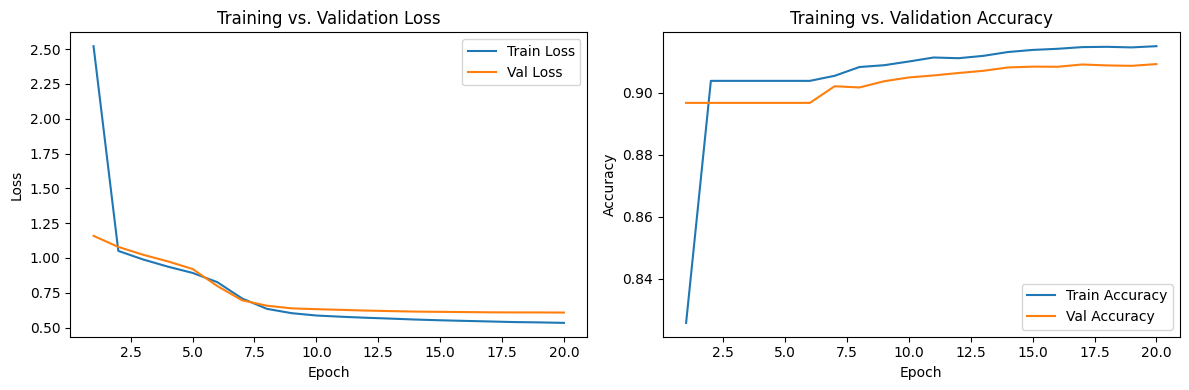

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9082 - loss: 0.6154
🧪 Test Loss: 0.6154
🧪 Test Accuracy (token-level): 0.9082
START_TOKEN id: 5
END_TOKEN id: 6
Test set size: 50
Test targets size: 50
✅ BLEU metric loaded successfully!
✅ BLEU evaluation utilities already imported from assignment3_utils.py
   Functions available:
   - add_python_hint(prompt)
   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)
   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)
   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)
✅ Python language hints added to test prompts
   Total prompts: 50

📝 Example transformation:
   Original: Write a python function to remove first and last occurrence of a given...
   With hint: Write a python function to remove first and last occurrence of a given...
🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE

📝 Prompt (original):
   Write a python function to remove first and last occurrence of a 

Part A generation: 100%|██████████| 50/50 [21:00<00:00, 25.20s/it]


🔬 Scoring PART A TRANSFORMER on 50 test examples (pre-generated)...


Part A Transformer BLEU Evaluation: 100%|██████████| 50/50 [00:00<00:00, 110.64it/s]



📊 PART A TRANSFORMER EVALUATION RESULTS
BLEU Score (mean):        0.91
BLEU Score (median):      0.66
BLEU Score (std dev):     0.88
BLEU Score (min):         0.00
BLEU Score (max):         4.33
Syntax Validity:          0/50 (0.0%)

✅ Part A Transformer evaluation complete!

💾 Results stored:
   - bleu_scores: list of 50 BLEU scores
   - syntax_valid: list of 50 validity booleans
   - generated_code: list of 50 generated code samples
   - stats: dictionary with mean, median, std, min, max, syntax stats
   - examples_with_scores: list of 50 example dicts

📊 DETAILED ANALYSIS: PART A TRANSFORMER


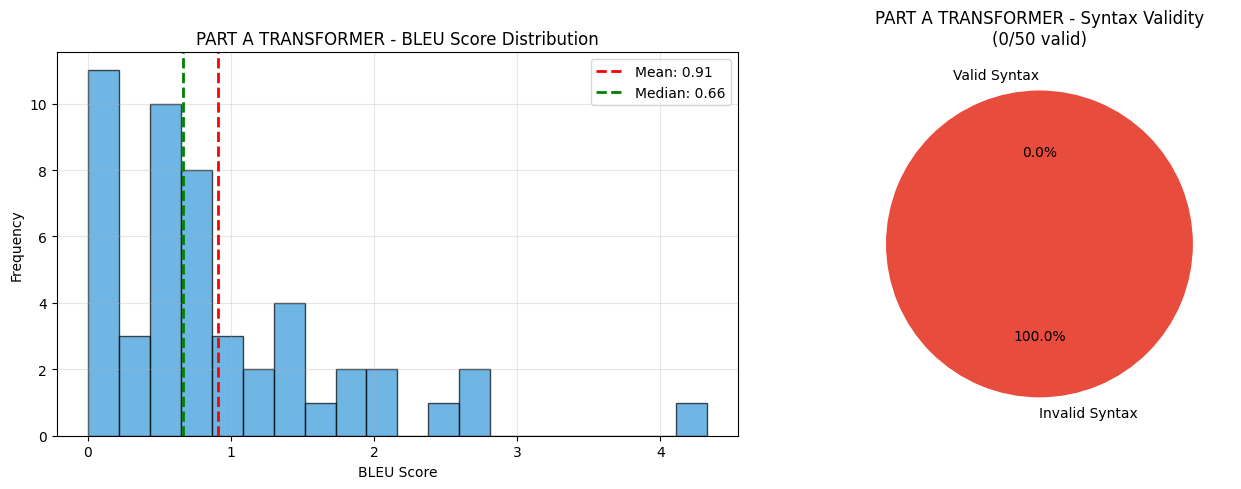


🏆 BEST PART A TRANSFORMER EXAMPLES (Highest BLEU)

Rank #1 - Example 15
BLEU Score: 4.33
Syntax Valid: False

📝 Prompt:
Write a python function to find the product of non-repeated elements in a given array.

🎯 Reference:
[START] def find_Product(arr,n): 
    arr.sort() 
    prod = 1
    for i in range(0,n,1): 
        if (arr[i - 1] != arr[i]): 
            prod =...

🤖 Generated (Part A Transformer):
[(max(x[0], [each element.append(lists[i]) max_sum_list(lists): lower list(zip(*temp)) "d", sorted(test_dict.keys(), recur_gcd(a, 3: high) num1) [abs(...

Rank #2 - Example 50
BLEU Score: 2.77
Syntax Valid: False

📝 Prompt:
Python:
Write a function to find the maximum length of the subsequence with difference between adjacent elements for the given array.

🎯 Reference:
[START] def max_len_sub( arr, n): 
	mls=[] 
	max = 0
	for i in range(n): 
		mls.append(1) 
	for i in range(n): 
		for j in range(i): 
			if (ab...

🤖 Generated (Part A Transformer):
c1) (decimal) heapq.heapify(temp) cmath.

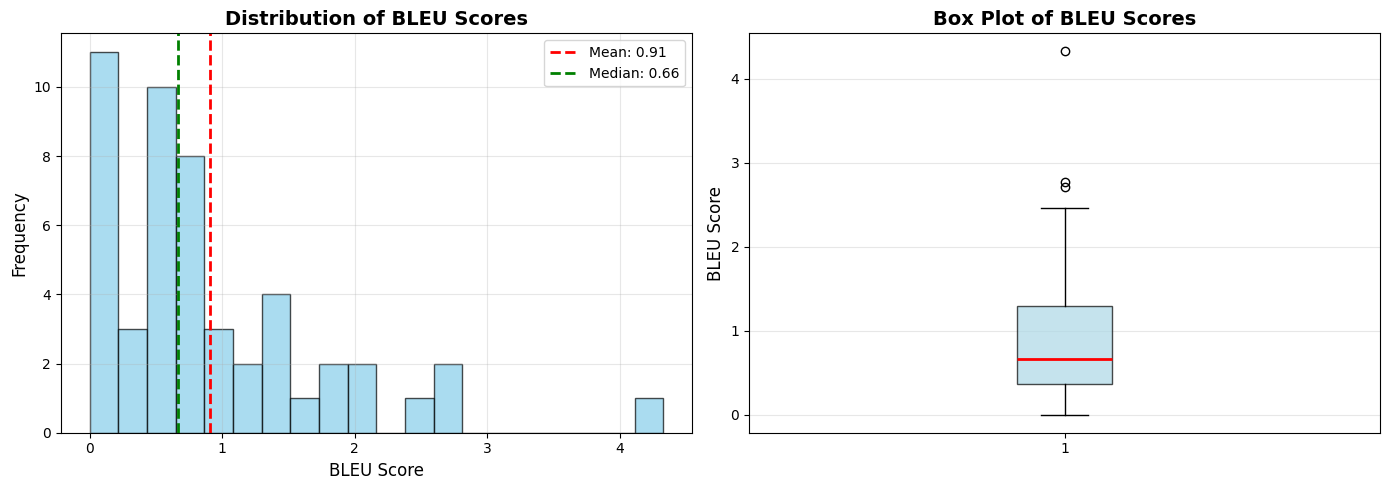


📊 From the visualization:
   - Most scores cluster around 0.66
   - Range: 0.00 to 4.33
   - Standard deviation: 0.88


In [49]:
from tensorflow.keras.layers import TextVectorization

# 🔧 Hyperparameters for tokenization
# --- EXPERIMENT HERE: vocabulary sizes and sequence lengths ---
MAX_INPUT_TOKENS = 12000   # vocabulary size for prompts
MAX_TARGET_TOKENS = 20000  # vocabulary size for code
MAX_INPUT_LENGTH = 128     # max tokens in the prompt
MAX_TARGET_LENGTH = 256    # max tokens in the code

START_TOKEN = "[START]"
END_TOKEN = "[END]"

print(f"✅ Updated vocabulary sizes:")
print(f"   Input vocab: {MAX_INPUT_TOKENS}")
print(f"   Target vocab: {MAX_TARGET_TOKENS}")

# ========================================
# ADD START/END TOKENS TO TARGETS
# ========================================

# Now that START_TOKEN and END_TOKEN are defined, add them to target sequences
train_inputs = train_prompts
train_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in train_code]

val_inputs = val_prompts
val_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in val_code]

test_inputs = test_prompts
test_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in test_code]

print(f"✅ Added START and END tokens to target sequences")
print(f"   Example target (first 100 chars): {train_targets[0][:100]}...")

# 🔹 Combine all data for vocabulary building

input_texts = train_inputs + val_inputs + test_inputs
target_texts = train_targets + val_targets + test_targets

print(f"Total examples for vocabulary: {len(input_texts)}")
print("\nSample description:\n", input_texts[0][:200], "...")
print("\nSample target with tokens:\n", target_texts[0][:200], "...")

# 🔹 Define simple standardization functions
# For this assignment, you will keep things relatively simple:
# - Lowercase everything
# - Do not aggressively strip punctuation (especially for code)

def simple_standardize_text(text):
    text = tf.strings.lower(text)
    return text

def simple_standardize_code(text):
    # You could customize this later if you want to handle code differently.
    text = tf.strings.lower(text)
    return text

# 🔹 Create TextVectorization layers for input (prompts) and target (code)

# Input (natural language prompt) vectorizer
input_vectorizer = TextVectorization(
    standardize=simple_standardize_text,
    max_tokens=MAX_INPUT_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_INPUT_LENGTH,
)

# Target (code) vectorizer
target_vectorizer = TextVectorization(
    standardize=simple_standardize_code,
    max_tokens=MAX_TARGET_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_TARGET_LENGTH,
)

# Adapt on the training text
input_vectorizer.adapt(input_texts)
target_vectorizer.adapt(target_texts)

print("✅ Vectorizers adapted on MBPP text and code.")


# 🔹 Inspect a few tokenized sequences

example_idx = 0

print("Original prompt:")
print(input_texts[example_idx])
print("\nVectorized prompt (first 40 ids):")
print(input_vectorizer([input_texts[example_idx]])[0][:40].numpy())

print("\nOriginal target with [START]/[END]:")
print(target_texts[example_idx])
print("\nVectorized target (first 40 ids):")
print(target_vectorizer([target_texts[example_idx]])[0][:40].numpy())


# 🔧 Hyperparameters for data pipeline
BATCH_SIZE = 32

# (Optional) separate constant for decoder sequence length:
DECODER_SEQ_LEN = MAX_TARGET_LENGTH - 1  # because we are shifting by 1

# 🔹 Vectorize all input and target texts

# Convert Python lists to numpy arrays for vectorization
input_texts_array = np.array(input_texts)
target_texts_array = np.array(target_texts)

encoder_input_data = input_vectorizer(input_texts_array)
full_target_data   = target_vectorizer(target_texts_array)

print("Encoder input shape:", encoder_input_data.shape)
print("Full target shape:", full_target_data.shape)

# 🔹 Build decoder input and target sequences (shifted)

# decoder_inputs: all tokens except the last
decoder_input_data = full_target_data[:, :-1]

# decoder_targets: all tokens except the first (shifted left by one)
decoder_target_data = full_target_data[:, 1:]

print("Decoder input shape:", decoder_input_data.shape)
print("Decoder target shape:", decoder_target_data.shape)

# 🔹 Vectorize the already-split datasets

# Training data
train_input_array = np.array(train_inputs)
train_target_array = np.array(train_targets)

train_encoder_in = input_vectorizer(train_input_array)
train_full_target = target_vectorizer(train_target_array)
train_decoder_in = train_full_target[:, :-1]
train_decoder_tgt = train_full_target[:, 1:]

# Validation data
val_input_array = np.array(val_inputs)
val_target_array = np.array(val_targets)

val_encoder_in = input_vectorizer(val_input_array)
val_full_target = target_vectorizer(val_target_array)
val_decoder_in = val_full_target[:, :-1]
val_decoder_tgt = val_full_target[:, 1:]

# Test data
test_input_array = np.array(test_inputs)
test_target_array = np.array(test_targets)

test_encoder_in = input_vectorizer(test_input_array)
test_full_target = target_vectorizer(test_target_array)
test_decoder_in = test_full_target[:, :-1]
test_decoder_tgt = test_full_target[:, 1:]

print("✅ Data vectorized and split")
print(f"Train encoder shape: {train_encoder_in.shape}")
print(f"Train decoder input shape: {train_decoder_in.shape}")
print(f"Train decoder target shape: {train_decoder_tgt.shape}")
print(f"\nVal encoder shape: {val_encoder_in.shape}")
print(f"Test encoder shape: {test_encoder_in.shape}")

# 🔹 Helper function to create a tf.data.Dataset

def make_transformer_dataset(encoder_inputs, decoder_inputs, decoder_targets, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            "encoder_inputs": encoder_inputs,
            "decoder_inputs": decoder_inputs,
        },
        decoder_targets,
    ))
    dataset = dataset.shuffle(buffer_size=len(encoder_inputs), seed=SEED)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_transformer_dataset(train_encoder_in, train_decoder_in, train_decoder_tgt)
val_ds   = make_transformer_dataset(val_encoder_in,   val_decoder_in,   val_decoder_tgt)
test_ds  = make_transformer_dataset(test_encoder_in,  test_decoder_in,  test_decoder_tgt)

train_ds, val_ds, test_ds


# 🔹 Peek at one batch to verify shapes

for batch in train_ds.take(1):
    batch_inputs, batch_targets = batch
    print("Keys in batch_inputs:", batch_inputs.keys())
    print("encoder_inputs shape:", batch_inputs["encoder_inputs"].shape)
    print("decoder_inputs shape:", batch_inputs["decoder_inputs"].shape)
    print("decoder_targets shape:", batch_targets.shape)


# Core Transformer hyperparameters
# --- EXPERIMENT HERE: model dimensions (D_MODEL must be divisible by NUM_HEADS) ---
D_MODEL = 512      # embedding / model dimension
NUM_HEADS = 8      # number of attention heads
D_FF = 1024         # feed-forward layer dimension (will be used later in blocks)
DROPOUT_RATE = 0.1


# Sanity check: create layer, pass zeros, verify shape
sample_pe_layer = PositionalEncoding(max_length=MAX_TARGET_LENGTH, d_model=D_MODEL)
test_input = tf.zeros((2, 10, D_MODEL))  # dummy batch
test_output = sample_pe_layer(test_input)
print("Positional encoding output shape:", test_output.shape)

# Sanity check: pass random Q, K, V through multi-head attention
temp_mha = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS)
dummy_q = tf.random.uniform((2, 10, D_MODEL))  # (batch, seq_len, d_model)
dummy_k = tf.random.uniform((2, 10, D_MODEL))
dummy_v = tf.random.uniform((2, 10, D_MODEL))

out, attn_w = temp_mha(v=dummy_v, k=dummy_k, q=dummy_q, mask=None)
print("Multi-head output shape:", out.shape)
print("Attention weights shape:", attn_w.shape)


# Sanity check: create masks from dummy sequences
dummy_seq = tf.constant([[7, 3, 0, 0, 0], [5, 2, 8, 0, 0]])
pad_mask = create_padding_mask(dummy_seq)
la_mask = create_look_ahead_mask(5)
dec_mask = create_decoder_mask(dummy_seq)
print("Padding mask shape:", pad_mask.shape)
print("Look-ahead mask shape:", la_mask.shape)
print("Decoder mask shape:", dec_mask.shape)


# Sanity check: pass dummy input through an encoder block
enc_block = EncoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_enc_input = tf.random.uniform((2, 10, D_MODEL))
enc_out = enc_block(dummy_enc_input, None, training=False)
print("Encoder block output shape:", enc_out.shape)

# Sanity check: pass dummy inputs through a decoder block
dec_block = DecoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_dec_input = tf.random.uniform((2, 8, D_MODEL))
dummy_enc_output = tf.random.uniform((2, 10, D_MODEL))
dec_out, _, _ = dec_block(dummy_dec_input, dummy_enc_output,
                          look_ahead_mask=None, padding_mask=None, training=False)
print("Decoder block output shape:", dec_out.shape)



input_vocab_size = len(input_vectorizer.get_vocabulary())
target_vocab_size = len(target_vectorizer.get_vocabulary())

# --- EXPERIMENT HERE: num_layers controls model depth ---
transformer = build_transformer_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    num_layers=2,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout_rate=DROPOUT_RATE,
    max_input_len=MAX_INPUT_LENGTH,
    max_target_len=MAX_TARGET_LENGTH - 1,
)

transformer.summary(line_length=120, expand_nested=True)


loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)

transformer.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # --- EXPERIMENT HERE: learning rate ---
    loss=loss_fn,
    metrics=["accuracy"],
)

print("✅ Transformer ready to train!")


EPOCHS = 20  # --- EXPERIMENT HERE: increase for better performance ---

checkpoint_path = "transformer_mbpp.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

print(f"✅ Model will be saved to: {checkpoint_path}")
print("✅ Callbacks set up. Ready to train!")


history = transformer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

plot_training_history(history)

test_loss, test_accuracy = transformer.evaluate(test_ds)
print(f"🧪 Test Loss: {test_loss:.4f}")
print(f"🧪 Test Accuracy (token-level): {test_accuracy:.4f}")

# Get target vocabulary and build lookup tables
target_vocab = target_vectorizer.get_vocabulary()
id_to_token = {i: tok for i, tok in enumerate(target_vocab)}
token_to_id = {tok: i for i, tok in enumerate(target_vocab)}

def get_token_id(token_str):
    """Try original token and lowercase version."""
    return token_to_id.get(token_str) or token_to_id.get(token_str.lower())

# Get IDs for special tokens
start_id = get_token_id(START_TOKEN)
end_id = get_token_id(END_TOKEN)

print("START_TOKEN id:", start_id)
print("END_TOKEN id:", end_id)

assert start_id is not None and end_id is not None, "Failed to find START/END token ids in vocab!"


# ------- EXPERIMENT HERE: Modify generation parameters -------

def generate_greedy(prompt_text):
    """Greedy decoding: always picks the most likely next token."""
    return generate_code_for_prompt(
        prompt_text,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
    )



# 🔹 Use the already-separated test data
test_prompts = test_inputs
test_target_strings = test_targets

print(f"Test set size: {len(test_prompts)}")
print(f"Test targets size: {len(test_target_strings)}")


# ========================================
# LOAD BLEU METRIC
# ========================================

import evaluate

# Load BLEU metric (uses sacrebleu implementation)
bleu_metric = evaluate.load("bleu")

print("✅ BLEU metric loaded successfully!")
print("✅ BLEU evaluation utilities already imported from assignment3_utils.py")
print("   Functions available:")
print("   - add_python_hint(prompt)")
print("   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)")
print("   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)")
print("   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)")


# ========================================
# APPLY PYTHON LANGUAGE HINTS TO TEST PROMPTS (Option A Improvement)
# ========================================
#
# Problem: Small transformer may generate ambiguous or invalid code
# Solution: Add "Python:" prefix to guide model to generate Python code
# This is the same fix that improved CodeT5 zero-shot from BLEU 0.00 → 10.77

# Apply Python hint to all test prompts
test_prompts_python = [add_python_hint(p) for p in test_prompts]

print("✅ Python language hints added to test prompts")
print(f"   Total prompts: {len(test_prompts_python)}")
print(f"\n📝 Example transformation:")
print(f"   Original: {test_prompts[0][:70]}...")
print(f"   With hint: {test_prompts_python[0][:70]}...")


# ========================================
# TEST ON A SINGLE EXAMPLE
# ========================================

# Define wrapper function for generate_best with Part A model parameters
def generate_code_wrapper(prompt):
    """Wrapper to call generate_best with Part A transformer-specific parameters."""
    return generate_best(
        prompt,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
        temperature=0.5,         # --- EXPERIMENT HERE ---
        repetition_penalty=1.5,  # --- EXPERIMENT HERE ---
    )

# Test on first example with Python hint applied
sample_prompt_original = test_prompts[0]
sample_prompt_python = add_python_hint(sample_prompt_original)  # Apply Python hint
sample_reference = test_target_strings[0]  # Already stripped of special tokens

print("=" * 80)
print("🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE")
print("=" * 80)

print(f"\n📝 Prompt (original):")
print(f"   {sample_prompt_original[:100]}...")

print(f"\n📝 Prompt (with Python hint):")
print(f"   {sample_prompt_python[:100]}...")

print(f"\n🎯 Reference code:")
print(f"   {sample_reference[:100]}...")

# Use shared compute_bleu_for_code function
bleu_score, is_valid_syntax, generated_code = compute_bleu_for_code(
    sample_prompt_python,  # Use Python-hinted prompt
    sample_reference,
    generate_code_wrapper,
    bleu_metric,
    model_label="Part A Transformer"
)

print(f"\n🤖 Generated code:")
print(f"   {generated_code[:100]}...")

print(f"\n📊 Results:")
print(f"   BLEU Score: {bleu_score:.2f}")
print(f"   Syntax Valid: {is_valid_syntax}")

print("\n" + "=" * 80)


# ========================================
# EVALUATE FULL TEST SET WITH BLEU
# ========================================

# Pre-generate all code first (shows progress bar), then score
# This provides consistent evaluation across Part A and Parts B/C
print("⚡ Generating all test code (sequential decoding)...")
parta_generated = sequential_generate_codes(
    test_prompts_python, generate_fn=generate_code_wrapper, desc="Part A generation"
)

bleu_scores, syntax_valid, generated_code, stats = evaluate_model_with_bleu(
    test_prompts_python,   # ← Use Python-hinted prompts (Option A)
    test_target_strings,   # Reference code (already stripped of special tokens)
    None,                  # ← No generate_fn needed (pre-generated)
    bleu_metric,           # ← Pass BLEU metric
    model_label="Part A Transformer",
    generated_codes=parta_generated,  # ← Pass pre-generated code
)

# Store results for later analysis
examples_with_scores = [
    {
        'idx': i,
        'prompt': test_prompts_python[i],
        'reference': test_target_strings[i],
        'generated': generated_code[i],
        'bleu': bleu_scores[i],
        'syntax_valid': syntax_valid[i]
    }
    for i in range(len(test_prompts_python))
]

print(f"\n💾 Results stored:")
print(f"   - bleu_scores: list of {len(bleu_scores)} BLEU scores")
print(f"   - syntax_valid: list of {len(syntax_valid)} validity booleans")
print(f"   - generated_code: list of {len(generated_code)} generated code samples")
print(f"   - stats: dictionary with mean, median, std, min, max, syntax stats")
print(f"   - examples_with_scores: list of {len(examples_with_scores)} example dicts")

# ========================================
# ANALYZE BEST AND WORST EXAMPLES
# ========================================

# Use shared analysis function from assignment3_utils
# This provides consistent analysis across Part A and Parts B/C

analyze_bleu_results(
    bleu_scores,
    syntax_valid,
    generated_code,
    test_prompts_python,  # Prompts with Python hints
    test_target_strings,  # Reference codes
    stats,
    model_label="Part A Transformer"
)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(bleu_scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Mean: {stats["mean"]:.2f}')
ax1.axvline(stats['median'], color='green', linestyle='--', linewidth=2, label=f'Median: {stats["median"]:.2f}')
ax1.set_xlabel('BLEU Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of BLEU Scores', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(bleu_scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('BLEU Score', fontsize=12)
ax2.set_title('Box Plot of BLEU Scores', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 From the visualization:")
print(f"   - Most scores cluster around {stats['median']:.2f}")
print(f"   - Range: {stats['min']:.2f} to {stats['max']:.2f}")
print(f"   - Standard deviation: {stats['std']:.2f}")

# Model 6

✅ Updated vocabulary sizes:
   Input vocab: 12000
   Target vocab: 20000
✅ Added START and END tokens to target sequences
   Example target (first 100 chars): [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_cha...
Total examples for vocabulary: 514

Sample description:
 Write a function to find the longest chain which can be formed from the given set of pairs. ...

Sample target with tokens:
 [START] class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)] 
	for i in range(1, n): 
		for j in ra ...
✅ Vectorizers adapted on MBPP text and code.
Original prompt:
Write a function to find the longest chain which can be formed from the given set of pairs.

Vectorized prompt (first 40 ids):
[  4   2   5   3   9   6 164 712  69  99  90 193  15   6   8 152   7 537
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]

Original

Model: "functional_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ encoder_inputs (InputLayer)       │ (None, 128)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_10 (Embedding)          │ (None, 128, 512)             │           397,824 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_inputs (InputLayer)       │ (None, 255)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_16            │ (None, 128, 512)             │                 0 │ embedding_10[0][0]        
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_11 (Embedding)          │ (None, 255, 512)             │         1,542,144 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_90 (Dropout)              │ (None, 128, 512)             │                 0 │ positional_encoding_16[0][
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_10 (Lambda)                │ (None, 1, 1, 128)            │                 0 │ encoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ positional_encoding_17            │ (None, 255, 512)             │                 0 │ embedding_11[0][0]        
│ (PositionalEncoding)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_16 (EncoderBlock)   │ (None, 128, 512)             │         2,102,784 │ dropout_90[0][0],         
│                                   │                              │                   │ lambda_10[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_95 (Dropout)              │ (None, 255, 512)             │                 0 │ positional_encoding_17[0][
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ encoder_block_17 (EncoderBlock)   │ (None, 128, 512)             │         2,102,784 │ encoder_block_16[0][0],   
│                                   │                              │                   │ lambda_10[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_11 (Lambda)                │ (None, 1, 255, 255)          │                 0 │ decoder_inputs[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ decoder_block_16 (DecoderBlock)   │ [(None, 255, 512), (None, 8, │         3,154,432 │ dropout_95[0][0],         
│                                   │ 255, 255), (None, 8, None,   │                   │ encoder_block_17[0][0],   
│                                   │ 128)]                        │                   │ lambda_11[0][0],          
│                                   │                   

 Total params: 13,999,556 (53.40 MB)

 Trainable params: 13,999,556 (53.40 MB)

 Non-trainable params: 0 (0.00 B)

✅ Transformer ready to train!
✅ Model will be saved to: transformer_mbpp.keras
✅ Callbacks set up. Ready to train!
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6694 - loss: 4.3299   
Epoch 1: val_loss improved from None to 1.19568, saving model to transformer_mbpp.keras

Epoch 1: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.8254 - loss: 2.5470 - val_accuracy: 0.8967 - val_loss: 1.1957
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9049 - loss: 1.0486
Epoch 2: val_loss improved from 1.19568 to 1.15903, saving model to transformer_mbpp.keras

Epoch 2: finished saving model to transformer_mbpp.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 0.9038 - loss: 1.0498 - val_accuracy: 0.8967 - val_loss: 1.1590
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9077 - loss: 0.9716
Epoch 3: val_loss improved from 1.15903 to 1.07242, saving model to transformer_mbpp.keras

Epoch 3:

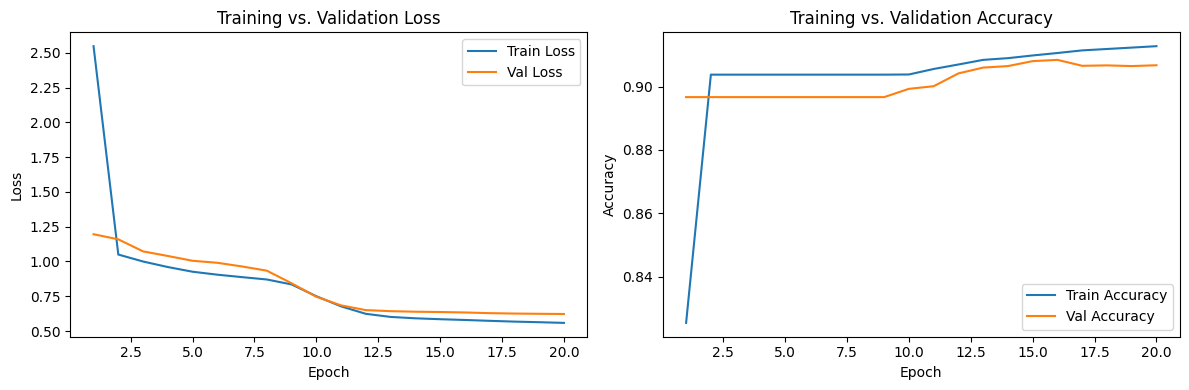

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9067 - loss: 0.6300
🧪 Test Loss: 0.6300
🧪 Test Accuracy (token-level): 0.9067
START_TOKEN id: 5
END_TOKEN id: 6
Test set size: 50
Test targets size: 50
✅ BLEU metric loaded successfully!
✅ BLEU evaluation utilities already imported from assignment3_utils.py
   Functions available:
   - add_python_hint(prompt)
   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)
   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)
   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)
✅ Python language hints added to test prompts
   Total prompts: 50

📝 Example transformation:
   Original: Write a python function to remove first and last occurrence of a given...
   With hint: Write a python function to remove first and last occurrence of a given...
🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE

📝 Prompt (original):
   Write a python function to remove first and last occurrence of a 

Part A generation: 100%|██████████| 50/50 [21:11<00:00, 25.43s/it]


🔬 Scoring PART A TRANSFORMER on 50 test examples (pre-generated)...


Part A Transformer BLEU Evaluation: 100%|██████████| 50/50 [00:00<00:00, 105.82it/s]



📊 PART A TRANSFORMER EVALUATION RESULTS
BLEU Score (mean):        0.74
BLEU Score (median):      0.60
BLEU Score (std dev):     0.78
BLEU Score (min):         0.00
BLEU Score (max):         3.03
Syntax Validity:          0/50 (0.0%)

✅ Part A Transformer evaluation complete!

💾 Results stored:
   - bleu_scores: list of 50 BLEU scores
   - syntax_valid: list of 50 validity booleans
   - generated_code: list of 50 generated code samples
   - stats: dictionary with mean, median, std, min, max, syntax stats
   - examples_with_scores: list of 50 example dicts

📊 DETAILED ANALYSIS: PART A TRANSFORMER


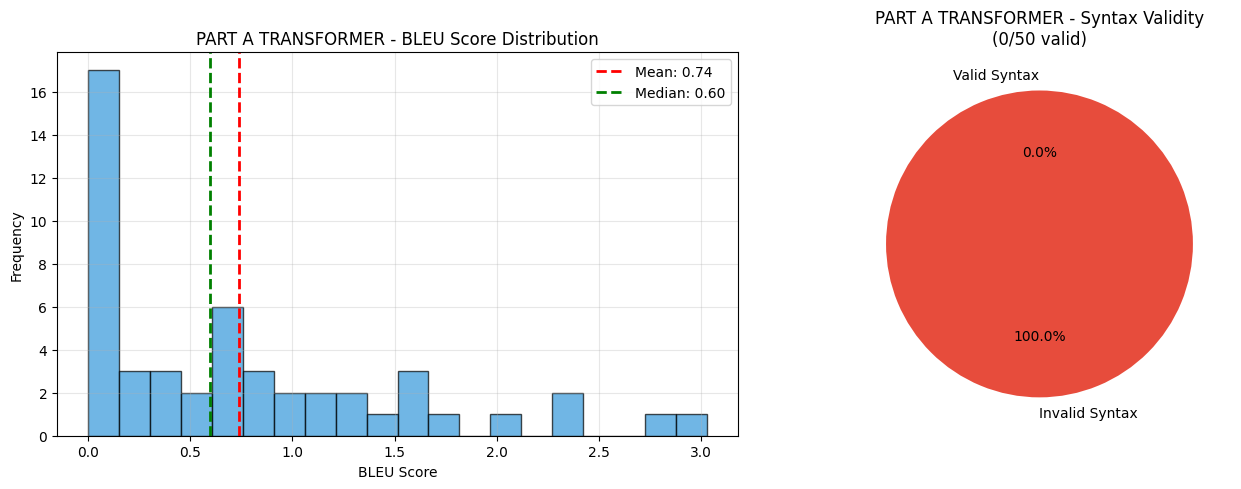


🏆 BEST PART A TRANSFORMER EXAMPLES (Highest BLEU)

Rank #1 - Example 8
BLEU Score: 3.03
Syntax Valid: False

📝 Prompt:
Python:
Write a function to remove characters from the first string which are present in the second string.

🎯 Reference:
[START] NO_OF_CHARS = 256
def str_to_list(string): 
	temp = [] 
	for x in string: 
		temp.append(x) 
	return temp 
def lst_to_string(List): 
	r...

🤖 Generated (Part A Transformer):
range(num): max_count arr[j] sample) len(s) mls[i] (first_even/first_odd) >=h generate_matrix(n): arr2, check_monthnum_number(monthnum1): dp[i][j] lud...

Rank #2 - Example 50
BLEU Score: 2.77
Syntax Valid: False

📝 Prompt:
Python:
Write a function to find the maximum length of the subsequence with difference between adjacent elements for the given array.

🎯 Reference:
[START] def max_len_sub( arr, n): 
	mls=[] 
	max = 0
	for i in range(n): 
		mls.append(1) 
	for i in range(n): 
		for j in range(i): 
			if (ab...

🤖 Generated (Part A Transformer):
num: dp[0][j start; (a

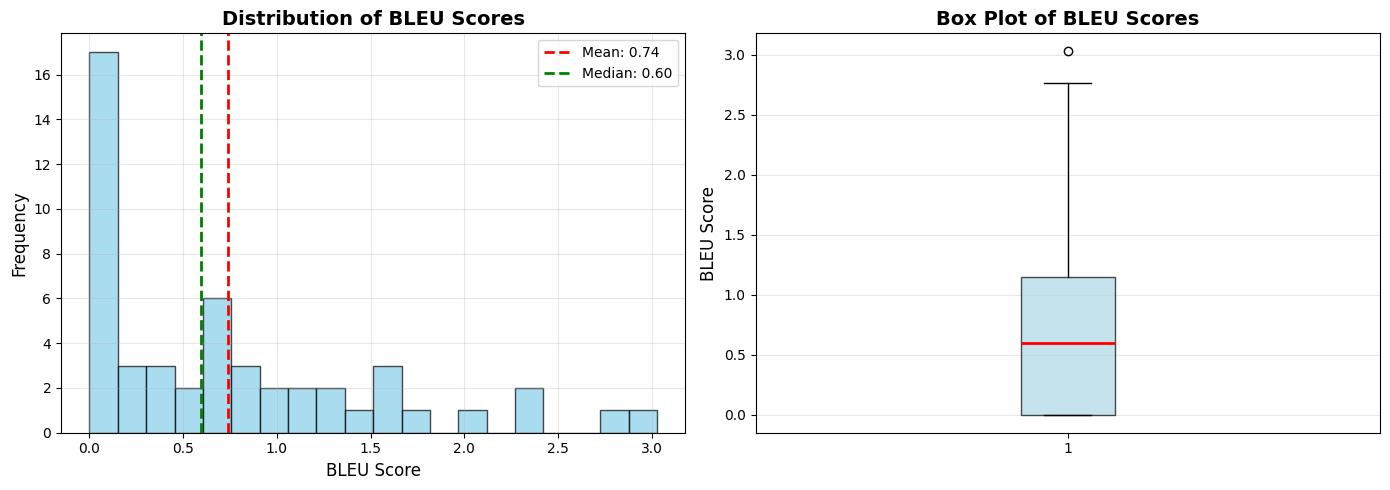


📊 From the visualization:
   - Most scores cluster around 0.60
   - Range: 0.00 to 3.03
   - Standard deviation: 0.78


In [50]:
from tensorflow.keras.layers import TextVectorization

# 🔧 Hyperparameters for tokenization
# --- EXPERIMENT HERE: vocabulary sizes and sequence lengths ---
MAX_INPUT_TOKENS = 12000   # vocabulary size for prompts
MAX_TARGET_TOKENS = 20000  # vocabulary size for code
MAX_INPUT_LENGTH = 128     # max tokens in the prompt
MAX_TARGET_LENGTH = 256    # max tokens in the code

START_TOKEN = "[START]"
END_TOKEN = "[END]"

print(f"✅ Updated vocabulary sizes:")
print(f"   Input vocab: {MAX_INPUT_TOKENS}")
print(f"   Target vocab: {MAX_TARGET_TOKENS}")

# ========================================
# ADD START/END TOKENS TO TARGETS
# ========================================

# Now that START_TOKEN and END_TOKEN are defined, add them to target sequences
train_inputs = train_prompts
train_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in train_code]

val_inputs = val_prompts
val_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in val_code]

test_inputs = test_prompts
test_targets = [f"{START_TOKEN} {c} {END_TOKEN}" for c in test_code]

print(f"✅ Added START and END tokens to target sequences")
print(f"   Example target (first 100 chars): {train_targets[0][:100]}...")

# 🔹 Combine all data for vocabulary building

input_texts = train_inputs + val_inputs + test_inputs
target_texts = train_targets + val_targets + test_targets

print(f"Total examples for vocabulary: {len(input_texts)}")
print("\nSample description:\n", input_texts[0][:200], "...")
print("\nSample target with tokens:\n", target_texts[0][:200], "...")

# 🔹 Define simple standardization functions
# For this assignment, you will keep things relatively simple:
# - Lowercase everything
# - Do not aggressively strip punctuation (especially for code)

def simple_standardize_text(text):
    text = tf.strings.lower(text)
    return text

def simple_standardize_code(text):
    # You could customize this later if you want to handle code differently.
    text = tf.strings.lower(text)
    return text

# 🔹 Create TextVectorization layers for input (prompts) and target (code)

# Input (natural language prompt) vectorizer
input_vectorizer = TextVectorization(
    standardize=simple_standardize_text,
    max_tokens=MAX_INPUT_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_INPUT_LENGTH,
)

# Target (code) vectorizer
target_vectorizer = TextVectorization(
    standardize=simple_standardize_code,
    max_tokens=MAX_TARGET_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_TARGET_LENGTH,
)

# Adapt on the training text
input_vectorizer.adapt(input_texts)
target_vectorizer.adapt(target_texts)

print("✅ Vectorizers adapted on MBPP text and code.")


# 🔹 Inspect a few tokenized sequences

example_idx = 0

print("Original prompt:")
print(input_texts[example_idx])
print("\nVectorized prompt (first 40 ids):")
print(input_vectorizer([input_texts[example_idx]])[0][:40].numpy())

print("\nOriginal target with [START]/[END]:")
print(target_texts[example_idx])
print("\nVectorized target (first 40 ids):")
print(target_vectorizer([target_texts[example_idx]])[0][:40].numpy())


# 🔧 Hyperparameters for data pipeline
BATCH_SIZE = 32

# (Optional) separate constant for decoder sequence length:
DECODER_SEQ_LEN = MAX_TARGET_LENGTH - 1  # because we are shifting by 1

# 🔹 Vectorize all input and target texts

# Convert Python lists to numpy arrays for vectorization
input_texts_array = np.array(input_texts)
target_texts_array = np.array(target_texts)

encoder_input_data = input_vectorizer(input_texts_array)
full_target_data   = target_vectorizer(target_texts_array)

print("Encoder input shape:", encoder_input_data.shape)
print("Full target shape:", full_target_data.shape)

# 🔹 Build decoder input and target sequences (shifted)

# decoder_inputs: all tokens except the last
decoder_input_data = full_target_data[:, :-1]

# decoder_targets: all tokens except the first (shifted left by one)
decoder_target_data = full_target_data[:, 1:]

print("Decoder input shape:", decoder_input_data.shape)
print("Decoder target shape:", decoder_target_data.shape)

# 🔹 Vectorize the already-split datasets

# Training data
train_input_array = np.array(train_inputs)
train_target_array = np.array(train_targets)

train_encoder_in = input_vectorizer(train_input_array)
train_full_target = target_vectorizer(train_target_array)
train_decoder_in = train_full_target[:, :-1]
train_decoder_tgt = train_full_target[:, 1:]

# Validation data
val_input_array = np.array(val_inputs)
val_target_array = np.array(val_targets)

val_encoder_in = input_vectorizer(val_input_array)
val_full_target = target_vectorizer(val_target_array)
val_decoder_in = val_full_target[:, :-1]
val_decoder_tgt = val_full_target[:, 1:]

# Test data
test_input_array = np.array(test_inputs)
test_target_array = np.array(test_targets)

test_encoder_in = input_vectorizer(test_input_array)
test_full_target = target_vectorizer(test_target_array)
test_decoder_in = test_full_target[:, :-1]
test_decoder_tgt = test_full_target[:, 1:]

print("✅ Data vectorized and split")
print(f"Train encoder shape: {train_encoder_in.shape}")
print(f"Train decoder input shape: {train_decoder_in.shape}")
print(f"Train decoder target shape: {train_decoder_tgt.shape}")
print(f"\nVal encoder shape: {val_encoder_in.shape}")
print(f"Test encoder shape: {test_encoder_in.shape}")

# 🔹 Helper function to create a tf.data.Dataset

def make_transformer_dataset(encoder_inputs, decoder_inputs, decoder_targets, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            "encoder_inputs": encoder_inputs,
            "decoder_inputs": decoder_inputs,
        },
        decoder_targets,
    ))
    dataset = dataset.shuffle(buffer_size=len(encoder_inputs), seed=SEED)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_transformer_dataset(train_encoder_in, train_decoder_in, train_decoder_tgt)
val_ds   = make_transformer_dataset(val_encoder_in,   val_decoder_in,   val_decoder_tgt)
test_ds  = make_transformer_dataset(test_encoder_in,  test_decoder_in,  test_decoder_tgt)

train_ds, val_ds, test_ds


# 🔹 Peek at one batch to verify shapes

for batch in train_ds.take(1):
    batch_inputs, batch_targets = batch
    print("Keys in batch_inputs:", batch_inputs.keys())
    print("encoder_inputs shape:", batch_inputs["encoder_inputs"].shape)
    print("decoder_inputs shape:", batch_inputs["decoder_inputs"].shape)
    print("decoder_targets shape:", batch_targets.shape)


# Core Transformer hyperparameters
# --- EXPERIMENT HERE: model dimensions (D_MODEL must be divisible by NUM_HEADS) ---
D_MODEL = 512      # embedding / model dimension
NUM_HEADS = 8      # number of attention heads
D_FF = 1024         # feed-forward layer dimension (will be used later in blocks)
DROPOUT_RATE = 0.3


# Sanity check: create layer, pass zeros, verify shape
sample_pe_layer = PositionalEncoding(max_length=MAX_TARGET_LENGTH, d_model=D_MODEL)
test_input = tf.zeros((2, 10, D_MODEL))  # dummy batch
test_output = sample_pe_layer(test_input)
print("Positional encoding output shape:", test_output.shape)

# Sanity check: pass random Q, K, V through multi-head attention
temp_mha = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS)
dummy_q = tf.random.uniform((2, 10, D_MODEL))  # (batch, seq_len, d_model)
dummy_k = tf.random.uniform((2, 10, D_MODEL))
dummy_v = tf.random.uniform((2, 10, D_MODEL))

out, attn_w = temp_mha(v=dummy_v, k=dummy_k, q=dummy_q, mask=None)
print("Multi-head output shape:", out.shape)
print("Attention weights shape:", attn_w.shape)


# Sanity check: create masks from dummy sequences
dummy_seq = tf.constant([[7, 3, 0, 0, 0], [5, 2, 8, 0, 0]])
pad_mask = create_padding_mask(dummy_seq)
la_mask = create_look_ahead_mask(5)
dec_mask = create_decoder_mask(dummy_seq)
print("Padding mask shape:", pad_mask.shape)
print("Look-ahead mask shape:", la_mask.shape)
print("Decoder mask shape:", dec_mask.shape)


# Sanity check: pass dummy input through an encoder block
enc_block = EncoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_enc_input = tf.random.uniform((2, 10, D_MODEL))
enc_out = enc_block(dummy_enc_input, None, training=False)
print("Encoder block output shape:", enc_out.shape)

# Sanity check: pass dummy inputs through a decoder block
dec_block = DecoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF)
dummy_dec_input = tf.random.uniform((2, 8, D_MODEL))
dummy_enc_output = tf.random.uniform((2, 10, D_MODEL))
dec_out, _, _ = dec_block(dummy_dec_input, dummy_enc_output,
                          look_ahead_mask=None, padding_mask=None, training=False)
print("Decoder block output shape:", dec_out.shape)



input_vocab_size = len(input_vectorizer.get_vocabulary())
target_vocab_size = len(target_vectorizer.get_vocabulary())

# --- EXPERIMENT HERE: num_layers controls model depth ---
transformer = build_transformer_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    num_layers=2,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout_rate=DROPOUT_RATE,
    max_input_len=MAX_INPUT_LENGTH,
    max_target_len=MAX_TARGET_LENGTH - 1,
)

transformer.summary(line_length=120, expand_nested=True)


loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)

transformer.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # --- EXPERIMENT HERE: learning rate ---
    loss=loss_fn,
    metrics=["accuracy"],
)

print("✅ Transformer ready to train!")


EPOCHS = 20  # --- EXPERIMENT HERE: increase for better performance ---

checkpoint_path = "transformer_mbpp.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

print(f"✅ Model will be saved to: {checkpoint_path}")
print("✅ Callbacks set up. Ready to train!")


history = transformer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

plot_training_history(history)

test_loss, test_accuracy = transformer.evaluate(test_ds)
print(f"🧪 Test Loss: {test_loss:.4f}")
print(f"🧪 Test Accuracy (token-level): {test_accuracy:.4f}")

# Get target vocabulary and build lookup tables
target_vocab = target_vectorizer.get_vocabulary()
id_to_token = {i: tok for i, tok in enumerate(target_vocab)}
token_to_id = {tok: i for i, tok in enumerate(target_vocab)}

def get_token_id(token_str):
    """Try original token and lowercase version."""
    return token_to_id.get(token_str) or token_to_id.get(token_str.lower())

# Get IDs for special tokens
start_id = get_token_id(START_TOKEN)
end_id = get_token_id(END_TOKEN)

print("START_TOKEN id:", start_id)
print("END_TOKEN id:", end_id)

assert start_id is not None and end_id is not None, "Failed to find START/END token ids in vocab!"


# ------- EXPERIMENT HERE: Modify generation parameters -------

def generate_greedy(prompt_text):
    """Greedy decoding: always picks the most likely next token."""
    return generate_code_for_prompt(
        prompt_text,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
    )



# 🔹 Use the already-separated test data
test_prompts = test_inputs
test_target_strings = test_targets

print(f"Test set size: {len(test_prompts)}")
print(f"Test targets size: {len(test_target_strings)}")


# ========================================
# LOAD BLEU METRIC
# ========================================

import evaluate

# Load BLEU metric (uses sacrebleu implementation)
bleu_metric = evaluate.load("bleu")

print("✅ BLEU metric loaded successfully!")
print("✅ BLEU evaluation utilities already imported from assignment3_utils.py")
print("   Functions available:")
print("   - add_python_hint(prompt)")
print("   - compute_bleu_for_code(prompt, reference, generate_fn, bleu_metric, label)")
print("   - evaluate_model_with_bleu(prompts, codes, generate_fn, bleu_metric, label)")
print("   - analyze_bleu_results(scores, valid, codes, prompts, refs, stats, label)")


# ========================================
# APPLY PYTHON LANGUAGE HINTS TO TEST PROMPTS (Option A Improvement)
# ========================================
#
# Problem: Small transformer may generate ambiguous or invalid code
# Solution: Add "Python:" prefix to guide model to generate Python code
# This is the same fix that improved CodeT5 zero-shot from BLEU 0.00 → 10.77

# Apply Python hint to all test prompts
test_prompts_python = [add_python_hint(p) for p in test_prompts]

print("✅ Python language hints added to test prompts")
print(f"   Total prompts: {len(test_prompts_python)}")
print(f"\n📝 Example transformation:")
print(f"   Original: {test_prompts[0][:70]}...")
print(f"   With hint: {test_prompts_python[0][:70]}...")


# ========================================
# TEST ON A SINGLE EXAMPLE
# ========================================

# Define wrapper function for generate_best with Part A model parameters
def generate_code_wrapper(prompt):
    """Wrapper to call generate_best with Part A transformer-specific parameters."""
    return generate_best(
        prompt,
        model=transformer,
        input_vectorizer=input_vectorizer,
        start_id=start_id,
        end_id=end_id,
        id_to_token=id_to_token,
        max_len=MAX_TARGET_LENGTH - 1,
        temperature=0.5,         # --- EXPERIMENT HERE ---
        repetition_penalty=1.5,  # --- EXPERIMENT HERE ---
    )

# Test on first example with Python hint applied
sample_prompt_original = test_prompts[0]
sample_prompt_python = add_python_hint(sample_prompt_original)  # Apply Python hint
sample_reference = test_target_strings[0]  # Already stripped of special tokens

print("=" * 80)
print("🧪 TESTING BLEU COMPUTATION ON SINGLE EXAMPLE")
print("=" * 80)

print(f"\n📝 Prompt (original):")
print(f"   {sample_prompt_original[:100]}...")

print(f"\n📝 Prompt (with Python hint):")
print(f"   {sample_prompt_python[:100]}...")

print(f"\n🎯 Reference code:")
print(f"   {sample_reference[:100]}...")

# Use shared compute_bleu_for_code function
bleu_score, is_valid_syntax, generated_code = compute_bleu_for_code(
    sample_prompt_python,  # Use Python-hinted prompt
    sample_reference,
    generate_code_wrapper,
    bleu_metric,
    model_label="Part A Transformer"
)

print(f"\n🤖 Generated code:")
print(f"   {generated_code[:100]}...")

print(f"\n📊 Results:")
print(f"   BLEU Score: {bleu_score:.2f}")
print(f"   Syntax Valid: {is_valid_syntax}")

print("\n" + "=" * 80)


# ========================================
# EVALUATE FULL TEST SET WITH BLEU
# ========================================

# Pre-generate all code first (shows progress bar), then score
# This provides consistent evaluation across Part A and Parts B/C
print("⚡ Generating all test code (sequential decoding)...")
parta_generated = sequential_generate_codes(
    test_prompts_python, generate_fn=generate_code_wrapper, desc="Part A generation"
)

bleu_scores, syntax_valid, generated_code, stats = evaluate_model_with_bleu(
    test_prompts_python,   # ← Use Python-hinted prompts (Option A)
    test_target_strings,   # Reference code (already stripped of special tokens)
    None,                  # ← No generate_fn needed (pre-generated)
    bleu_metric,           # ← Pass BLEU metric
    model_label="Part A Transformer",
    generated_codes=parta_generated,  # ← Pass pre-generated code
)

# Store results for later analysis
examples_with_scores = [
    {
        'idx': i,
        'prompt': test_prompts_python[i],
        'reference': test_target_strings[i],
        'generated': generated_code[i],
        'bleu': bleu_scores[i],
        'syntax_valid': syntax_valid[i]
    }
    for i in range(len(test_prompts_python))
]

print(f"\n💾 Results stored:")
print(f"   - bleu_scores: list of {len(bleu_scores)} BLEU scores")
print(f"   - syntax_valid: list of {len(syntax_valid)} validity booleans")
print(f"   - generated_code: list of {len(generated_code)} generated code samples")
print(f"   - stats: dictionary with mean, median, std, min, max, syntax stats")
print(f"   - examples_with_scores: list of {len(examples_with_scores)} example dicts")

# ========================================
# ANALYZE BEST AND WORST EXAMPLES
# ========================================

# Use shared analysis function from assignment3_utils
# This provides consistent analysis across Part A and Parts B/C

analyze_bleu_results(
    bleu_scores,
    syntax_valid,
    generated_code,
    test_prompts_python,  # Prompts with Python hints
    test_target_strings,  # Reference codes
    stats,
    model_label="Part A Transformer"
)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(bleu_scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Mean: {stats["mean"]:.2f}')
ax1.axvline(stats['median'], color='green', linestyle='--', linewidth=2, label=f'Median: {stats["median"]:.2f}')
ax1.set_xlabel('BLEU Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of BLEU Scores', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(bleu_scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('BLEU Score', fontsize=12)
ax2.set_title('Box Plot of BLEU Scores', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 From the visualization:")
print(f"   - Most scores cluster around {stats['median']:.2f}")
print(f"   - Range: {stats['min']:.2f} to {stats['max']:.2f}")
print(f"   - Standard deviation: {stats['std']:.2f}")

## 🎓 Summary: What We Learned

### Key Findings

1. **High Training Accuracy ≠ Good Generation**
   - Training accuracy: ~89%, BLEU: ~0.96, Syntax validity: 0%
   - Teacher forcing metrics don't predict autoregressive quality

2. **Small Models Fail at Code Generation**
   - Our model: ~1M parameters vs Industry: 220M+ (pretrained on millions)
   - Autoregressive error: 0.89^50 ≈ 0% for 50-token sequences

3. **BLEU Scores**: 0-10 (guessing), 10-30 (unreliable), 30-50 (decent), 50+ (strong)
   - Our ~0.77 shows the model hasn't learned meaningful patterns

### Next Steps

**Parts B & C** will show the production approach:
- Part B: Pretrained models (zero-shot) → Expected 10-50x BLEU improvement
- Part C: Fine-tuning → Production-ready code generation

**Bottom line:** Our from-scratch model demonstrates WHY pretrained models exist!

In [51]:
NOTEBOOK_END_TIME = datetime.now()
elapsed = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
total_mins, total_secs = divmod(int(elapsed.total_seconds()), 60)
print(f"✅ Notebook complete")
print(f"Total time:  {total_mins}m {total_secs}s")
print(f"Current time: {NOTEBOOK_END_TIME.strftime('%Y-%m-%d %H:%M:%S')}")

✅ Notebook complete
Total time:  150m 54s
Current time: 2026-08-02 01:43:55
